<a href="https://colab.research.google.com/github/nikhilkoushik/Flight_booking_predections/blob/main/Capstone_project_Group_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project Revised Notebook


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. File paths



In [2]:
BASE_DIR = "/content"

TASK1_PATH = os.path.join(BASE_DIR, "/content/task1_gecs_classification_final.csv")
TASK2_PATH = os.path.join(BASE_DIR, "/content/task2_subindustry_classification_final.csv")
ACTIVITY_BOOK_PATH = os.path.join(BASE_DIR, "/content/GECS Activity book.csv")

## 2. Load files

In [3]:
df1 = pd.read_csv(TASK1_PATH)
df2 = pd.read_csv(TASK2_PATH)
activity_book = pd.read_csv(ACTIVITY_BOOK_PATH)

print("Task 1 shape:", df1.shape)
print("Task 2 shape:", df2.shape)
print("Activity book shape:", activity_book.shape)

Task 1 shape: (53585, 10)
Task 2 shape: (27537, 5)
Activity book shape: (450, 5)


In [4]:
print("Task 1 columns:")
print(df1.columns.tolist())

print("\nTask 2 columns:")
print(df2.columns.tolist())

print("\nActivity book columns:")
print(activity_book.columns.tolist())

Task 1 columns:
['CompanyId', 'AsOfDate', 'LongProfile', 'SegmentName', 'SegmentDescription', 'Revenue', 'total_revenue_company_as_of', 'revenue_share', 'is_largest_share_segment', 'MstarGlobal']

Task 2 columns:
['CompanyId', 'AsOfDate', 'SegmentName', 'SegmentDescription', 'SubIndustry']

Activity book columns:
['Activity ID', 'Activity', 'Activity Definition', 'Industry ID', 'Industry']


## 3. Build taxonomy maps from the GECS activity book

This replaces all manual dictionaries.

In [5]:
activity_book["Industry ID"] = activity_book["Industry ID"].astype(str).str.strip()
activity_book["Activity ID"] = activity_book["Activity ID"].astype(str).str.strip()

industry_map = (
    activity_book[["Industry ID", "Industry"]]
    .drop_duplicates()
    .rename(columns={"Industry ID": "IndustryCode", "Industry": "IndustryName"})
)

activity_map = (
    activity_book[["Activity ID", "Activity", "Activity Definition", "Industry ID", "Industry"]]
    .drop_duplicates()
    .rename(columns={
        "Activity ID": "ActivityCode",
        "Activity": "ActivityName",
        "Activity Definition": "ActivityDefinition",
        "Industry ID": "IndustryCode",
        "Industry": "IndustryName"
    })
)

print("Industry count in map:", industry_map["IndustryCode"].nunique())
print("Activity count in map:", activity_map["ActivityCode"].nunique())

display(industry_map.head())
display(activity_map.head())

Industry count in map: 145
Activity count in map: 450


,IndustryCode,IndustryName
0,10110010,Agricultural Inputs
5,10120010,Building Materials
12,10130010,Chemicals
17,10130020,Specialty Chemicals
28,10140010,Lumber & Wood Production


,ActivityCode,ActivityName,ActivityDefinition,IndustryCode,IndustryName
0,1011001001,Pesticide and Agrichemical Manufacturer,Companies engaged in the manufacturing of pest...,10110010,Agricultural Inputs
1,1011001002,Anhydrous Ammonia Manufacturer,Companies engaged in the manufacturing of anhy...,10110010,Agricultural Inputs
2,1011001003,Agricultural Input Distributor,"Companies engaged in trading, exporting, and d...",10110010,Agricultural Inputs
3,1011001004,Fertilizer Manufacturer,Companies engaged in the manufacturing of fert...,10110010,Agricultural Inputs
4,1011001005,Nitric Acid Manufacturer,Companies engaged in the manufacturing of nitr...,10110010,Agricultural Inputs


## 4. Enrich Task 1 with readable industry names

In [6]:
df1["MstarGlobal"] = df1["MstarGlobal"].astype(str).str.strip()
df1["MstarGlobalCode"] = df1["MstarGlobal"]

df1 = df1.merge(
    industry_map,
    left_on="MstarGlobalCode",
    right_on="IndustryCode",
    how="left"
)

# Replace the coded label with the readable name
df1["MstarGlobal"] = df1["IndustryName"]
df1["SegmentDescription"] = df1["SegmentDescription"].fillna("")

display(df1[["CompanyId", "SegmentName", "MstarGlobal", "MstarGlobalCode"]].head())

,CompanyId,SegmentName,MstarGlobal,MstarGlobalCode
0,AX2S5G3YJ2,Frozen & Vegetables,Packaged Foods,20525040
1,AX2S5G3YJ2,Meals,Packaged Foods,20525040
2,AX2S5G3YJ2,Specialty,Packaged Foods,20525040
3,AX2S5G3YJ2,Spices & Flavor Solutions,Packaged Foods,20525040
4,3IZBDS5MVU,Raw Materials and Other,Semiconductor Equipment & Materials,31130010


## 5. Enrich Task 2 with readable activity names

In [7]:
df2["SubIndustry"] = df2["SubIndustry"].astype(str).str.strip()
df2["SubIndustryCode"] = df2["SubIndustry"]

df2 = df2.merge(
    activity_map,
    left_on="SubIndustryCode",
    right_on="ActivityCode",
    how="left"
)

# Replace the coded label with the readable activity name
df2["SubIndustry"] = df2["ActivityName"]
df2["ParentIndustryCodeFromActivity"] = df2["SubIndustryCode"].str[:8]

display(df2[["CompanyId", "SegmentName", "SubIndustry", "SubIndustryCode", "IndustryName"]].head())

,CompanyId,SegmentName,SubIndustry,SubIndustryCode,IndustryName
0,3IZBDS5MVU,Substrates,Semiconductor Equipment & Materials,3113001001,Semiconductor Equipment & Materials
1,3IZBDS5MVU,Raw Materials and Other,Semiconductor Equipment & Materials,3113001001,Semiconductor Equipment & Materials
2,AX2S5G3YJ2,Frozen & Vegetables,Packaged or Frozen Food Manufacturer,2052504001,Packaged Foods
3,AX2S5G3YJ2,Meals,Packaged or Frozen Food Manufacturer,2052504001,Packaged Foods
4,AX2S5G3YJ2,Specialty,Packaged or Frozen Food Manufacturer,2052504001,Packaged Foods


## 6. Validate the mapping

In [8]:
print("Task 1 missing mapped industry names:", df1["MstarGlobal"].isna().sum())
print("Task 2 missing mapped activity names:", df2["SubIndustry"].isna().sum())
print("Task 2 missing parent industry names:", df2["IndustryName"].isna().sum())

Task 1 missing mapped industry names: 0
Task 2 missing mapped activity names: 0
Task 2 missing parent industry names: 0


## 7. Basic dataset overview

In [9]:
overview = pd.DataFrame([
    {
        "dataset": "Task 1",
        "rows": len(df1),
        "unique_companies": df1["CompanyId"].nunique(),
        "unique_classes": df1["MstarGlobal"].nunique()
    },
    {
        "dataset": "Task 2",
        "rows": len(df2),
        "unique_companies": df2["CompanyId"].nunique(),
        "unique_classes": df2["SubIndustry"].nunique()
    }
])

overview

,dataset,rows,unique_companies,unique_classes
0,Task 1,53585,23207,145
1,Task 2,27537,9352,428


## 8. Missing value summary

In [10]:
def missing_summary(df):
    return pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing Percent": (df.isnull().mean() * 100).round(2)
    }).sort_values(by="Missing Count", ascending=False)

display(missing_summary(df1).head(15))
display(missing_summary(df2).head(15))

,Missing Count,Missing Percent
CompanyId,0,0.0
AsOfDate,0,0.0
LongProfile,0,0.0
SegmentName,0,0.0
SegmentDescription,0,0.0
Revenue,0,0.0
total_revenue_company_as_of,0,0.0
revenue_share,0,0.0
is_largest_share_segment,0,0.0
MstarGlobal,0,0.0


,Missing Count,Missing Percent
CompanyId,0,0.0
AsOfDate,0,0.0
SegmentName,0,0.0
SegmentDescription,0,0.0
SubIndustry,0,0.0
SubIndustryCode,0,0.0
ActivityCode,0,0.0
ActivityName,0,0.0
ActivityDefinition,0,0.0
IndustryCode,0,0.0


## 9. Text diagnostics

In [11]:
df1["LongProfile_length"] = df1["LongProfile"].fillna("").astype(str).str.len()
df1["SegmentDescription_length"] = df1["SegmentDescription"].fillna("").astype(str).str.len()
df2["SegmentDescription_length"] = df2["SegmentDescription"].fillna("").astype(str).str.len()

print(df1[["LongProfile_length", "SegmentDescription_length"]].describe())
print(df2[["SegmentDescription_length"]].describe())

       LongProfile_length  SegmentDescription_length
count        53585.000000               53585.000000
mean           514.260203                 101.485864
std            185.115092                 136.261807
min             31.000000                   0.000000
25%            377.000000                   0.000000
50%            529.000000                   0.000000
75%            671.000000                 166.000000
max            812.000000                 520.000000
       SegmentDescription_length
count               27537.000000
mean                  208.638269
std                   125.465420
min                    22.000000
25%                   110.000000
50%                   170.000000
75%                   281.000000
max                   520.000000


## 10. Revenue checks for Task 1

In [12]:
print(df1[["Revenue", "total_revenue_company_as_of", "revenue_share"]].describe())

anomalies = df1[(df1["revenue_share"] < 0) | (df1["revenue_share"] > 1)]
print("Rows with unusual revenue_share:", len(anomalies))
display(anomalies[["CompanyId", "SegmentName", "Revenue", "revenue_share"]].head(10))

            Revenue  total_revenue_company_as_of  revenue_share
count  5.358500e+04                 5.358500e+04   53585.000000
mean   6.983377e+13                 2.097876e+14       0.433088
std    1.046236e+16                 2.784890e+16       0.841642
min   -4.139714e+12                -4.376729e+09    -107.175403
25%    6.591468e+07                 3.650180e+08       0.083100
50%    6.990010e+08                 3.435000e+09       0.309435
75%    7.045047e+09                 3.272200e+10       0.859270
max    1.796362e+18                 3.722006e+18     107.175403
Rows with unusual revenue_share: 287


,CompanyId,SegmentName,Revenue,revenue_share
20,PC2W5WSGEQ,All Other,-7.629000e+09,-0.074425
30,M7AFDHZYNU,Investment banking,-1.822800e+10,-0.000814
38,W22H2R63AE,Other,-3.184000e+09,-0.094565
77,WFY2KXIIDI,Treasury and Other,-1.218140e+08,-0.190600
78,VNAGGCWWW2,"Other, Treasury and Corporate (OT&C)",-6.603000e+09,-0.497289
83,5XVP5GC5IJ,Corporate Services,-5.700000e+08,-0.017381
542,NBDSBHDNSG,Other and Eliminations,-2.460000e+07,-0.031250
1008,WOQHXQI2PJ,Corporate,-2.380000e+08,-0.074608
1262,5KBTLFVPAC,Other,-2.027000e+09,-0.438840
1431,5BHRSLQTLI,Nonconsolidated JV revenue,-1.810020e+10,-3.943914


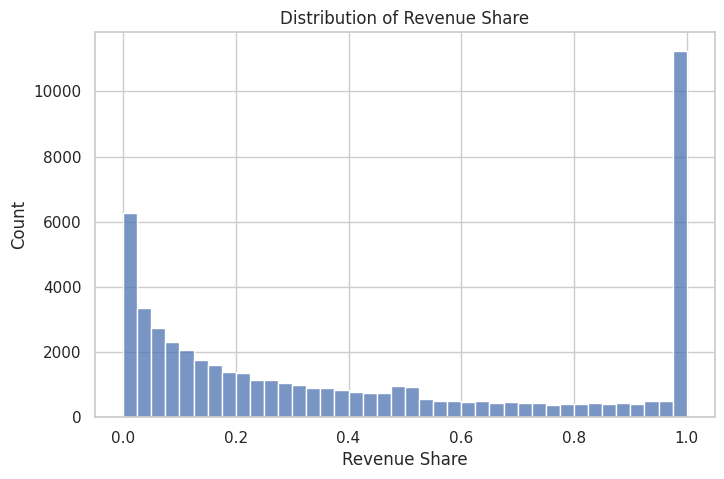

In [13]:
valid_share = df1[df1["revenue_share"].between(0, 1)]

plt.figure(figsize=(8, 5))
sns.histplot(valid_share["revenue_share"], bins=40)
plt.title("Distribution of Revenue Share")
plt.xlabel("Revenue Share")
plt.ylabel("Count")
plt.show()

## 11. Top classes with readable names

In [14]:
task1_top = df1["MstarGlobal"].value_counts().head(10)
task2_top = df2["SubIndustry"].value_counts().head(10)

display(task1_top)
display(task2_top)

,count
MstarGlobal,
Asset Management,2359
Conglomerates,2358
Banks - Regional,2165
Real Estate Services,1632
Engineering & Construction,1358
Specialty Industrial Machinery,1250
Software - Application,1226
Packaged Foods,1185
Drug Manufacturers - Specialty & Generic,1160


,count
SubIndustry,
Conglomerates,2018
Acquisition and Ownership of Buildings,682
Regional Retail Banking,623
Investment Management,593
Packaged or Frozen Food Manufacturer,495
Other Chemical Products Manufacturer,465
Other Engineering Projects,455
Heavy Industrial Machinery Manufacturer,425
Credit Provider,403


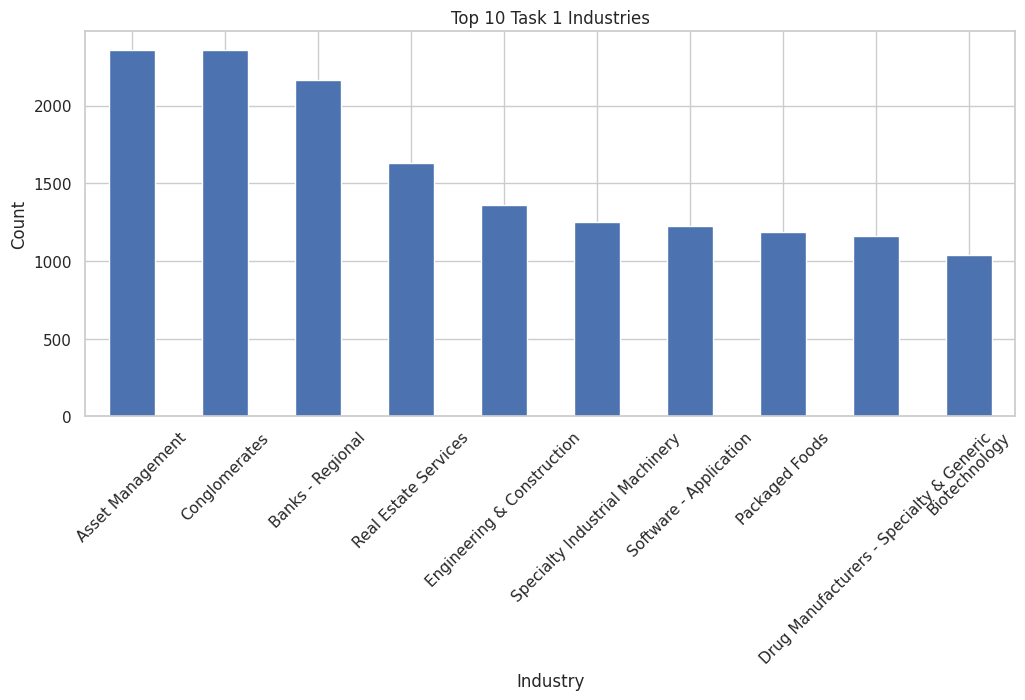

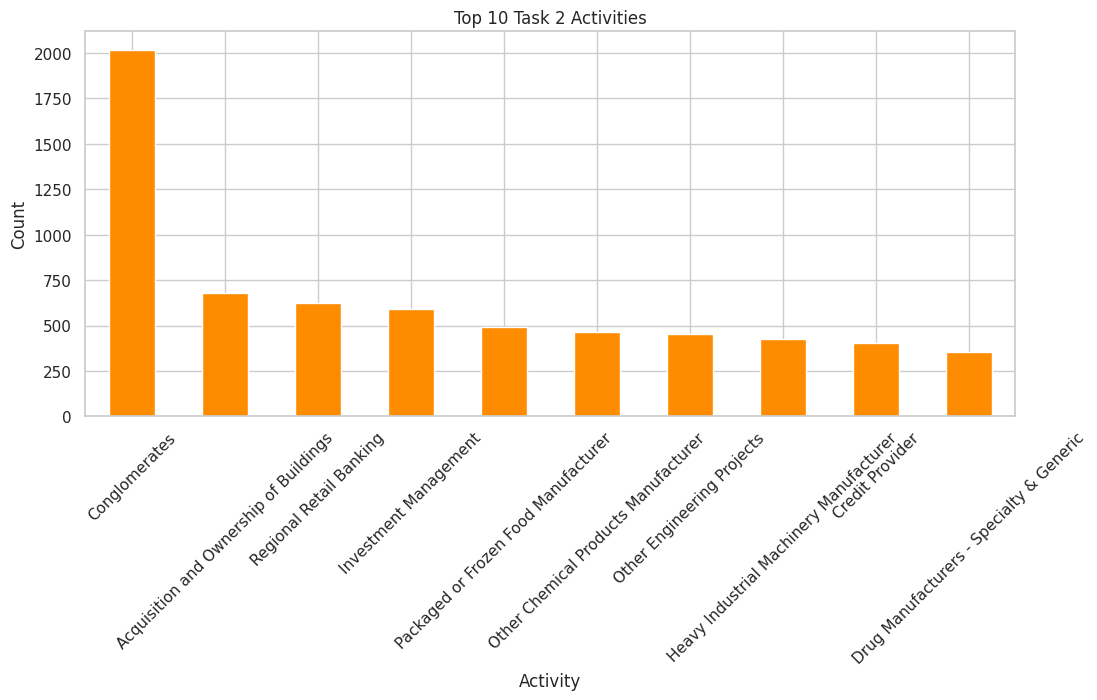

In [15]:
plt.figure(figsize=(12, 5))
task1_top.plot(kind="bar")
plt.title("Top 10 Task 1 Industries")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 5))
task2_top.plot(kind="bar", color="darkorange")
plt.title("Top 10 Task 2 Activities")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 12. Segments per company-date in Task 1

count    23207.000000
mean         2.309002
std          1.712625
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         32.000000
Name: SegmentName, dtype: float64


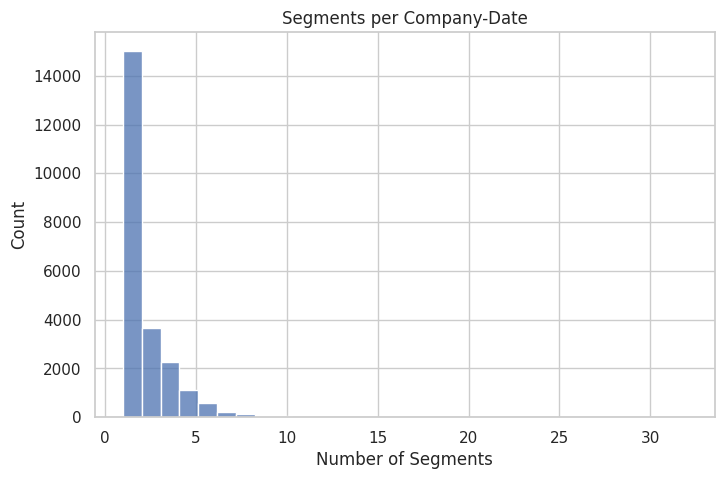

In [16]:
segments_per_company_date = df1.groupby(["CompanyId", "AsOfDate"])["SegmentName"].count()
print(segments_per_company_date.describe())

plt.figure(figsize=(8, 5))
sns.histplot(segments_per_company_date, bins=30)
plt.title("Segments per Company-Date")
plt.xlabel("Number of Segments")
plt.ylabel("Count")
plt.show()

## 13. Create a proper company-date Task 1 dataset

We sort each company-date by revenue and use the largest-revenue segment as the canonical label.

In [17]:
df1_full_enriched = df1.copy()

# Basic cleaning
df1_full_enriched["AsOfDate"] = pd.to_datetime(df1_full_enriched["AsOfDate"])
df1_full_enriched["LongProfile"] = df1_full_enriched["LongProfile"].fillna("")
df1_full_enriched["SegmentName"] = df1_full_enriched["SegmentName"].fillna("")
df1_full_enriched["SegmentDescription"] = df1_full_enriched["SegmentDescription"].fillna("")

# Combined text for analysis / modeling
df1_full_enriched["Combined_Text"] = (
    df1_full_enriched["LongProfile"] + " " +
    df1_full_enriched["SegmentName"] + " " +
    df1_full_enriched["SegmentDescription"]
).str.strip()

# Useful helper features
df1_full_enriched["SegmentCount"] = (
    df1_full_enriched.groupby(["CompanyId", "AsOfDate"])["SegmentName"].transform("count")
)
df1_full_enriched["row_level_label_count"] = (
    df1_full_enriched.groupby(["CompanyId", "AsOfDate"])["MstarGlobalCode"].transform("nunique")
)
df1_full_enriched["has_multiple_row_labels"] = (
    df1_full_enriched["row_level_label_count"] > 1
)
df1_full_enriched["LatestCompanyDateFlag"] = (
    df1_full_enriched["AsOfDate"] == df1_full_enriched.groupby("CompanyId")["AsOfDate"].transform("max")
)

# Mark the highest-revenue row inside each company-date group
canonical_index = (
    df1_full_enriched
    .sort_values(["CompanyId", "AsOfDate", "Revenue"], ascending=[True, True, False])
    .groupby(["CompanyId", "AsOfDate"])
    .head(1)
    .index
)

df1_full_enriched["Is_Canonical_CompanyDate_Row"] = False
df1_full_enriched.loc[canonical_index, "Is_Canonical_CompanyDate_Row"] = True

print("Original Task 1 rows:", len(df1))
print("Full enriched Task 1 rows:", len(df1_full_enriched))
display(df1_full_enriched.head())


Original Task 1 rows: 53585
Full enriched Task 1 rows: 53585


,CompanyId,AsOfDate,LongProfile,SegmentName,SegmentDescription,Revenue,total_revenue_company_as_of,revenue_share,is_largest_share_segment,MstarGlobal,...,IndustryCode,IndustryName,LongProfile_length,SegmentDescription_length,Combined_Text,SegmentCount,row_level_label_count,has_multiple_row_labels,LatestCompanyDateFlag,Is_Canonical_CompanyDate_Row
0,AX2S5G3YJ2,2024-12-31,The company is an American packaged-food manuf...,Frozen & Vegetables,Frozen & Vegetables segment includes the Green...,395785000.0,1.932454e+09,0.204810,False,Packaged Foods,...,20525040,Packaged Foods,712,73,The company is an American packaged-food manuf...,4,1,False,True,False
1,AX2S5G3YJ2,2024-12-31,The company is an American packaged-food manuf...,Meals,"Meals segment includes, among others, the Orte...",462397000.0,1.932454e+09,0.239280,False,Packaged Foods,...,20525040,Packaged Foods,712,175,The company is an American packaged-food manuf...,4,1,False,True,False
2,AX2S5G3YJ2,2024-12-31,The company is an American packaged-food manuf...,Specialty,"Specialty segment includes, among others, the ...",679076000.0,1.932454e+09,0.351406,True,Packaged Foods,...,20525040,Packaged Foods,712,238,The company is an American packaged-food manuf...,4,1,False,True,True
3,AX2S5G3YJ2,2024-12-31,The company is an American packaged-food manuf...,Spices & Flavor Solutions,"Spices & Flavor Solutions segment includes, am...",395196000.0,1.932454e+09,0.204505,False,Packaged Foods,...,20525040,Packaged Foods,712,145,The company is an American packaged-food manuf...,4,1,False,True,False
4,3IZBDS5MVU,2024-12-31,The company is a developer and producer of com...,Raw Materials and Other,,31613000.0,9.936100e+07,0.318163,False,Semiconductor Equipment & Materials,...,31130010,Semiconductor Equipment & Materials,804,0,The company is a developer and producer of com...,2,1,False,True,False


In [18]:
print("Original Task 1 rows:", len(df1))
print("Full enriched Task 1 rows:", len(df1_full_enriched))
print("Unique companies:", df1_full_enriched["CompanyId"].nunique())
print("Unique company-date groups:", df1_full_enriched[["CompanyId", "AsOfDate"]].drop_duplicates().shape[0])
print("Rows with multiple row-level labels:", int(df1_full_enriched["has_multiple_row_labels"].sum()))


Original Task 1 rows: 53585
Full enriched Task 1 rows: 53585
Unique companies: 23207
Unique company-date groups: 23207
Rows with multiple row-level labels: 29554


## 14. Create a latest-snapshot modeling dataset

This step creates a one-row-per-company modeling base without changing the full enriched dataset.


In [19]:
task1_latest = (
    df1_full_enriched[
        df1_full_enriched["LatestCompanyDateFlag"] &
        df1_full_enriched["Is_Canonical_CompanyDate_Row"]
    ]
    .sort_values(["CompanyId", "AsOfDate"], ascending=[True, False])
    .drop_duplicates(subset=["CompanyId"], keep="first")
    .copy()
)

print("Latest-snapshot rows:", len(task1_latest))
print("Unique companies:", task1_latest["CompanyId"].nunique())
print("Unique industries:", task1_latest["MstarGlobal"].nunique())

display(task1_latest.head())


Latest-snapshot rows: 23207
Unique companies: 23207
Unique industries: 145


,CompanyId,AsOfDate,LongProfile,SegmentName,SegmentDescription,Revenue,total_revenue_company_as_of,revenue_share,is_largest_share_segment,MstarGlobal,...,IndustryCode,IndustryName,LongProfile_length,SegmentDescription_length,Combined_Text,SegmentCount,row_level_label_count,has_multiple_row_labels,LatestCompanyDateFlag,Is_Canonical_CompanyDate_Row
8256,222INBEM3Z,2024-06-30,The company is an independent diamond mining c...,Mining activities,Mining activities segment is engaged in the ex...,3.670000e+08,3.670000e+08,1.000000,True,Other Precious Metals & Mining,...,10150060,Other Precious Metals & Mining,653,134,The company is an independent diamond mining c...,2,1,False,True,True
24126,2233XDWXWG,2024-10-31,The company is a diversified closed-end manage...,Single Segment,,2.964617e+07,2.964617e+07,1.000000,True,Asset Management,...,10310010,Asset Management,381,0,The company is a diversified closed-end manage...,1,1,False,True,True
45427,2267QN22YC,2024-06-30,The company operates in two segments: cable ne...,Television,"Television produces, acquires, markets and dis...",7.875000e+09,1.403900e+10,0.560937,True,Entertainment,...,30820040,Entertainment,649,426,The company operates in two segments: cable ne...,3,1,False,True,True
42115,226NJJMPAU,2024-12-31,The company is a biotechnology company that de...,Single segment,,3.013000e+06,3.013000e+06,1.000000,True,Biotechnology,...,20610010,Biotechnology,753,0,The company is a biotechnology company that de...,1,1,False,True,True
8839,227B3JCK33,2024-11-30,The company is a business technology group. Th...,K3 Products,K3 Products provides software products and sol...,1.234000e+07,2.321700e+07,0.531507,True,Software - Application,...,31110020,Software - Application,563,418,The company is a business technology group. Th...,2,2,True,True,True


## 15. Create cleaner export and modeling tables for Task 1


In [20]:
# Keep all original rows, but export only the columns that are actually useful
task1_export_columns = [
    "CompanyId",
    "AsOfDate",
    "LongProfile",
    "SegmentName",
    "SegmentDescription",
    "Revenue",
    "total_revenue_company_as_of",
    "revenue_share",
    "is_largest_share_segment",
    "MstarGlobal",
    "MstarGlobalCode",
    "Combined_Text",
    "SegmentCount",
    "row_level_label_count",
    "has_multiple_row_labels",
    "LatestCompanyDateFlag",
    "Is_Canonical_CompanyDate_Row"
]

task1_export = df1_full_enriched[task1_export_columns].copy()

model_data_task1 = task1_latest[[
    "CompanyId",
    "AsOfDate",
    "Combined_Text",
    "SegmentCount",
    "revenue_share",
    "has_multiple_row_labels",
    "MstarGlobal",
    "MstarGlobalCode"
]].copy()

task1_class_counts = model_data_task1["MstarGlobal"].value_counts()
top20_task1_classes = task1_class_counts.head(20).index
model_data_task1_top20 = model_data_task1[
    model_data_task1["MstarGlobal"].isin(top20_task1_classes)
].copy()

print("Full export table shape:", task1_export.shape)
print("Full Task 1 modeling table shape:", model_data_task1.shape)
print("Task 1 top-20 modeling table shape:", model_data_task1_top20.shape)
print("Task 1 top-20 unique classes:", model_data_task1_top20["MstarGlobal"].nunique())
display(task1_export.head())


Full export table shape: (53585, 17)
Full Task 1 modeling table shape: (23207, 8)
Task 1 top-20 modeling table shape: (10443, 8)
Task 1 top-20 unique classes: 20


,CompanyId,AsOfDate,LongProfile,SegmentName,SegmentDescription,Revenue,total_revenue_company_as_of,revenue_share,is_largest_share_segment,MstarGlobal,MstarGlobalCode,Combined_Text,SegmentCount,row_level_label_count,has_multiple_row_labels,LatestCompanyDateFlag,Is_Canonical_CompanyDate_Row
0,AX2S5G3YJ2,2024-12-31,The company is an American packaged-food manuf...,Frozen & Vegetables,Frozen & Vegetables segment includes the Green...,395785000.0,1.932454e+09,0.204810,False,Packaged Foods,20525040,The company is an American packaged-food manuf...,4,1,False,True,False
1,AX2S5G3YJ2,2024-12-31,The company is an American packaged-food manuf...,Meals,"Meals segment includes, among others, the Orte...",462397000.0,1.932454e+09,0.239280,False,Packaged Foods,20525040,The company is an American packaged-food manuf...,4,1,False,True,False
2,AX2S5G3YJ2,2024-12-31,The company is an American packaged-food manuf...,Specialty,"Specialty segment includes, among others, the ...",679076000.0,1.932454e+09,0.351406,True,Packaged Foods,20525040,The company is an American packaged-food manuf...,4,1,False,True,True
3,AX2S5G3YJ2,2024-12-31,The company is an American packaged-food manuf...,Spices & Flavor Solutions,"Spices & Flavor Solutions segment includes, am...",395196000.0,1.932454e+09,0.204505,False,Packaged Foods,20525040,The company is an American packaged-food manuf...,4,1,False,True,False
4,3IZBDS5MVU,2024-12-31,The company is a developer and producer of com...,Raw Materials and Other,,31613000.0,9.936100e+07,0.318163,False,Semiconductor Equipment & Materials,31130010,The company is a developer and producer of com...,2,1,False,True,False


## Task 2 full enriched dataset

This keeps all original Task 2 rows and creates a clean enriched export table before the Task 1 train/test split.


In [21]:
df2_full_enriched = df2.copy()

# Basic cleaning
df2_full_enriched["AsOfDate"] = pd.to_datetime(df2_full_enriched["AsOfDate"])
df2_full_enriched["SegmentName"] = df2_full_enriched["SegmentName"].fillna("")
df2_full_enriched["SegmentDescription"] = df2_full_enriched["SegmentDescription"].fillna("")
df2_full_enriched["SubIndustryCode"] = df2_full_enriched["SubIndustryCode"].astype(str)

# Combined text
df2_full_enriched["Combined_Text"] = (
    df2_full_enriched["SegmentName"] + " " +
    df2_full_enriched["SegmentDescription"]
).str.strip()

# Parent industry from activity code prefix
df2_full_enriched["ParentIndustryCode"] = df2_full_enriched["SubIndustryCode"].str[:8]

parent_industry_map = industry_map.rename(columns={
    "IndustryCode": "ParentIndustryCode",
    "IndustryName": "ParentIndustryName"
})

df2_full_enriched = df2_full_enriched.merge(
    parent_industry_map,
    on="ParentIndustryCode",
    how="left"
)

print("Original Task 2 rows:", len(df2))
print("Full enriched Task 2 rows:", len(df2_full_enriched))
display(df2_full_enriched.head())


Original Task 2 rows: 27537
Full enriched Task 2 rows: 27537


,CompanyId,AsOfDate,SegmentName,SegmentDescription,SubIndustry,SubIndustryCode,ActivityCode,ActivityName,ActivityDefinition,IndustryCode,IndustryName,ParentIndustryCodeFromActivity,SegmentDescription_length,Combined_Text,ParentIndustryCode,ParentIndustryName
0,3IZBDS5MVU,2020-12-31,Substrates,"Substrates engages in the design, development,...",Semiconductor Equipment & Materials,3113001001,3113001001,Semiconductor Equipment & Materials,Companies engaged in the manufacturing of equi...,31130010,Semiconductor Equipment & Materials,31130010,150,"Substrates Substrates engages in the design, d...",31130010,Semiconductor Equipment & Materials
1,3IZBDS5MVU,2020-12-31,Raw Materials and Other,Raw Materials and Other pertains to the sale o...,Semiconductor Equipment & Materials,3113001001,3113001001,Semiconductor Equipment & Materials,Companies engaged in the manufacturing of equi...,31130010,Semiconductor Equipment & Materials,31130010,105,Raw Materials and Other Raw Materials and Othe...,31130010,Semiconductor Equipment & Materials
2,AX2S5G3YJ2,2024-12-31,Frozen & Vegetables,Frozen & Vegetables segment includes the Green...,Packaged or Frozen Food Manufacturer,2052504001,2052504001,Packaged or Frozen Food Manufacturer,Companies engaged in the processing and manufa...,20525040,Packaged Foods,20525040,73,Frozen & Vegetables Frozen & Vegetables segmen...,20525040,Packaged Foods
3,AX2S5G3YJ2,2024-12-31,Meals,"Meals segment includes, among others, the Orte...",Packaged or Frozen Food Manufacturer,2052504001,2052504001,Packaged or Frozen Food Manufacturer,Companies engaged in the processing and manufa...,20525040,Packaged Foods,20525040,175,"Meals Meals segment includes, among others, th...",20525040,Packaged Foods
4,AX2S5G3YJ2,2024-12-31,Specialty,"Specialty segment includes, among others, the ...",Packaged or Frozen Food Manufacturer,2052504001,2052504001,Packaged or Frozen Food Manufacturer,Companies engaged in the processing and manufa...,20525040,Packaged Foods,20525040,238,"Specialty Specialty segment includes, among ot...",20525040,Packaged Foods


In [22]:
task2_export_columns = [
    "CompanyId",
    "AsOfDate",
    "SegmentName",
    "SegmentDescription",
    "SubIndustry",
    "SubIndustryCode",
    "ActivityName",
    "ActivityDefinition",
    "ParentIndustryCode",
    "ParentIndustryName",
    "Combined_Text"
]

task2_export = df2_full_enriched[task2_export_columns].copy()

print("Task 2 export shape:", task2_export.shape)
display(task2_export.head())


Task 2 export shape: (27537, 11)


,CompanyId,AsOfDate,SegmentName,SegmentDescription,SubIndustry,SubIndustryCode,ActivityName,ActivityDefinition,ParentIndustryCode,ParentIndustryName,Combined_Text
0,3IZBDS5MVU,2020-12-31,Substrates,"Substrates engages in the design, development,...",Semiconductor Equipment & Materials,3113001001,Semiconductor Equipment & Materials,Companies engaged in the manufacturing of equi...,31130010,Semiconductor Equipment & Materials,"Substrates Substrates engages in the design, d..."
1,3IZBDS5MVU,2020-12-31,Raw Materials and Other,Raw Materials and Other pertains to the sale o...,Semiconductor Equipment & Materials,3113001001,Semiconductor Equipment & Materials,Companies engaged in the manufacturing of equi...,31130010,Semiconductor Equipment & Materials,Raw Materials and Other Raw Materials and Othe...
2,AX2S5G3YJ2,2024-12-31,Frozen & Vegetables,Frozen & Vegetables segment includes the Green...,Packaged or Frozen Food Manufacturer,2052504001,Packaged or Frozen Food Manufacturer,Companies engaged in the processing and manufa...,20525040,Packaged Foods,Frozen & Vegetables Frozen & Vegetables segmen...
3,AX2S5G3YJ2,2024-12-31,Meals,"Meals segment includes, among others, the Orte...",Packaged or Frozen Food Manufacturer,2052504001,Packaged or Frozen Food Manufacturer,Companies engaged in the processing and manufa...,20525040,Packaged Foods,"Meals Meals segment includes, among others, th..."
4,AX2S5G3YJ2,2024-12-31,Specialty,"Specialty segment includes, among others, the ...",Packaged or Frozen Food Manufacturer,2052504001,Packaged or Frozen Food Manufacturer,Companies engaged in the processing and manufa...,20525040,Packaged Foods,"Specialty Specialty segment includes, among ot..."


In [23]:
# Uncomment if you want to save Task 2 exports
task2_export.to_csv("task2_full_enriched.csv", index=False)
# task2_export.to_excel("task2_full_enriched.xlsx", index=False)
# print("Task 2 files saved successfully.")


## 16. Example safe train/test split for Task 1

This uses the one-row-per-company modeling table. The full enriched export table still keeps all original rows.


In [24]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    model_data_task1_top20,
    test_size=0.2,
    random_state=42,
    stratify=model_data_task1_top20["MstarGlobal"]
)

print("Task 1 top-20 train shape:", train_df.shape)
print("Task 1 top-20 test shape:", test_df.shape)
print("Task 1 company overlap:", len(set(train_df["CompanyId"]).intersection(set(test_df["CompanyId"]))))

Task 1 top-20 train shape: (8354, 8)
Task 1 top-20 test shape: (2089, 8)
Task 1 company overlap: 0


## 17. Save cleaned datasets if needed

In [25]:
# Save the full-row export dataset without losing any original Task 1 rows
# Uncomment the lines you want to run

task1_export.to_csv("task1_full_enriched.csv", index=False)
# task1_export.to_excel("task1_full_enriched.xlsx", index=False)

# Save the one-row-per-company modeling dataset separately
# task1_latest.to_csv("task1_latest_snapshot.csv", index=False)
# task1_latest.to_excel("task1_latest_snapshot.xlsx", index=False)

# model_data_task1.to_csv("task1_model_data.csv", index=False)

# print("Files saved successfully.")


In [26]:
summary_overview = pd.DataFrame([
    {
        "Dataset": "Task 1",
        "Rows": len(task1_export),
        "Unique Companies": task1_export["CompanyId"].nunique(),
        "Unique Classes": task1_export["MstarGlobal"].nunique()
    },
    {
        "Dataset": "Task 2",
        "Rows": len(task2_export),
        "Unique Companies": task2_export["CompanyId"].nunique(),
        "Unique Classes": task2_export["SubIndustry"].nunique()
    }
])

summary_overview


,Dataset,Rows,Unique Companies,Unique Classes
0,Task 1,53585,23207,145
1,Task 2,27537,9352,428


In [27]:
def missing_summary(df):
    return pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing Percent": (df.isnull().mean() * 100).round(2)
    }).sort_values("Missing Count", ascending=False)

print("Task 1 missing summary")
display(missing_summary(task1_export))

print("Task 2 missing summary")
display(missing_summary(task2_export))


Task 1 missing summary


,Missing Count,Missing Percent
CompanyId,0,0.0
AsOfDate,0,0.0
LongProfile,0,0.0
SegmentName,0,0.0
SegmentDescription,0,0.0
Revenue,0,0.0
total_revenue_company_as_of,0,0.0
revenue_share,0,0.0
is_largest_share_segment,0,0.0
MstarGlobal,0,0.0


Task 2 missing summary


,Missing Count,Missing Percent
CompanyId,0,0.0
AsOfDate,0,0.0
SegmentName,0,0.0
SegmentDescription,0,0.0
SubIndustry,0,0.0
SubIndustryCode,0,0.0
ActivityName,0,0.0
ActivityDefinition,0,0.0
ParentIndustryCode,0,0.0
ParentIndustryName,0,0.0


In [28]:
task1_class_dist = task1_export["MstarGlobal"].value_counts().reset_index()
task1_class_dist.columns = ["MstarGlobal", "Count"]
task1_class_dist["Percent"] = (task1_class_dist["Count"] / task1_class_dist["Count"].sum() * 100).round(2)

display(task1_class_dist.head(20))


,MstarGlobal,Count,Percent
0,Asset Management,2359,4.40
1,Conglomerates,2358,4.40
2,Banks - Regional,2165,4.04
3,Real Estate Services,1632,3.05
4,Engineering & Construction,1358,2.53
5,Specialty Industrial Machinery,1250,2.33
6,Software - Application,1226,2.29
7,Packaged Foods,1185,2.21
8,Drug Manufacturers - Specialty & Generic,1160,2.16
9,Biotechnology,1036,1.93


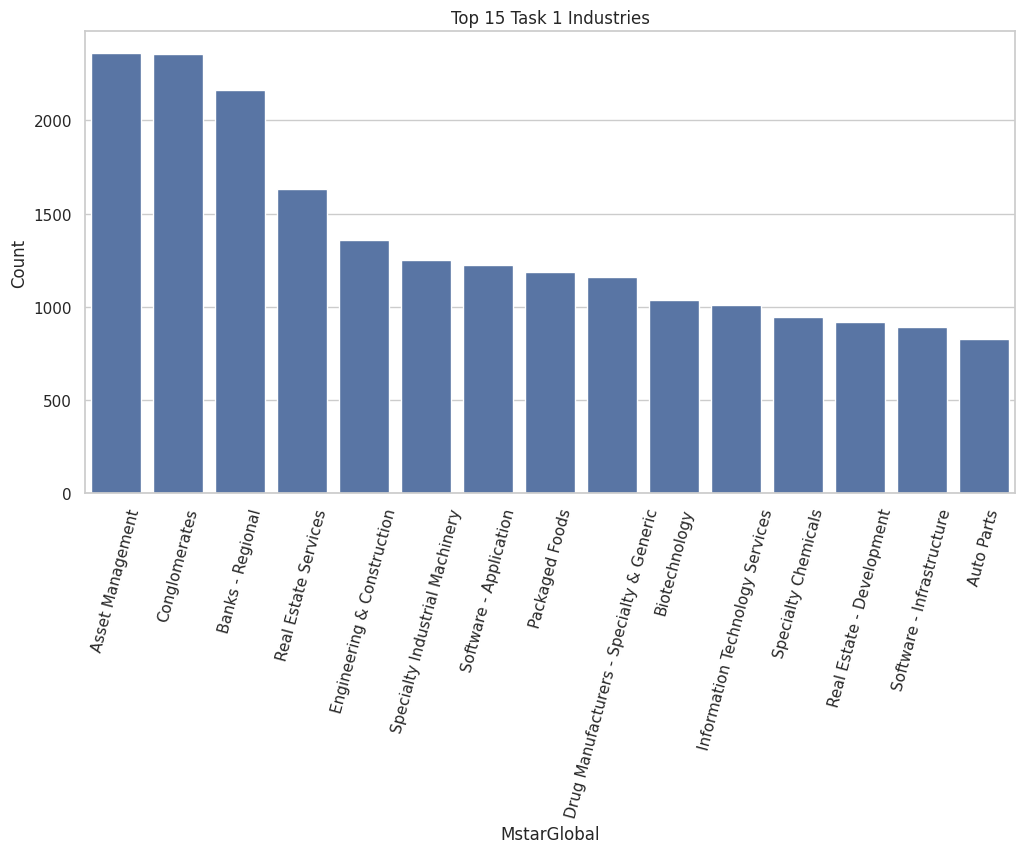

In [29]:
plt.figure(figsize=(12, 6))
sns.barplot(data=task1_class_dist.head(15), x="MstarGlobal", y="Count")
plt.title("Top 15 Task 1 Industries")
plt.xticks(rotation=75)
plt.show()


In [30]:
task2_class_dist = task2_export["SubIndustry"].value_counts().reset_index()
task2_class_dist.columns = ["SubIndustry", "Count"]
task2_class_dist["Percent"] = (task2_class_dist["Count"] / task2_class_dist["Count"].sum() * 100).round(2)

display(task2_class_dist.head(20))


,SubIndustry,Count,Percent
0,Conglomerates,2018,7.33
1,Acquisition and Ownership of Buildings,682,2.48
2,Regional Retail Banking,623,2.26
3,Investment Management,593,2.15
4,Packaged or Frozen Food Manufacturer,495,1.80
5,Other Chemical Products Manufacturer,465,1.69
6,Other Engineering Projects,455,1.65
7,Heavy Industrial Machinery Manufacturer,425,1.54
8,Credit Provider,403,1.46
9,Drug Manufacturers - Specialty & Generic,354,1.29


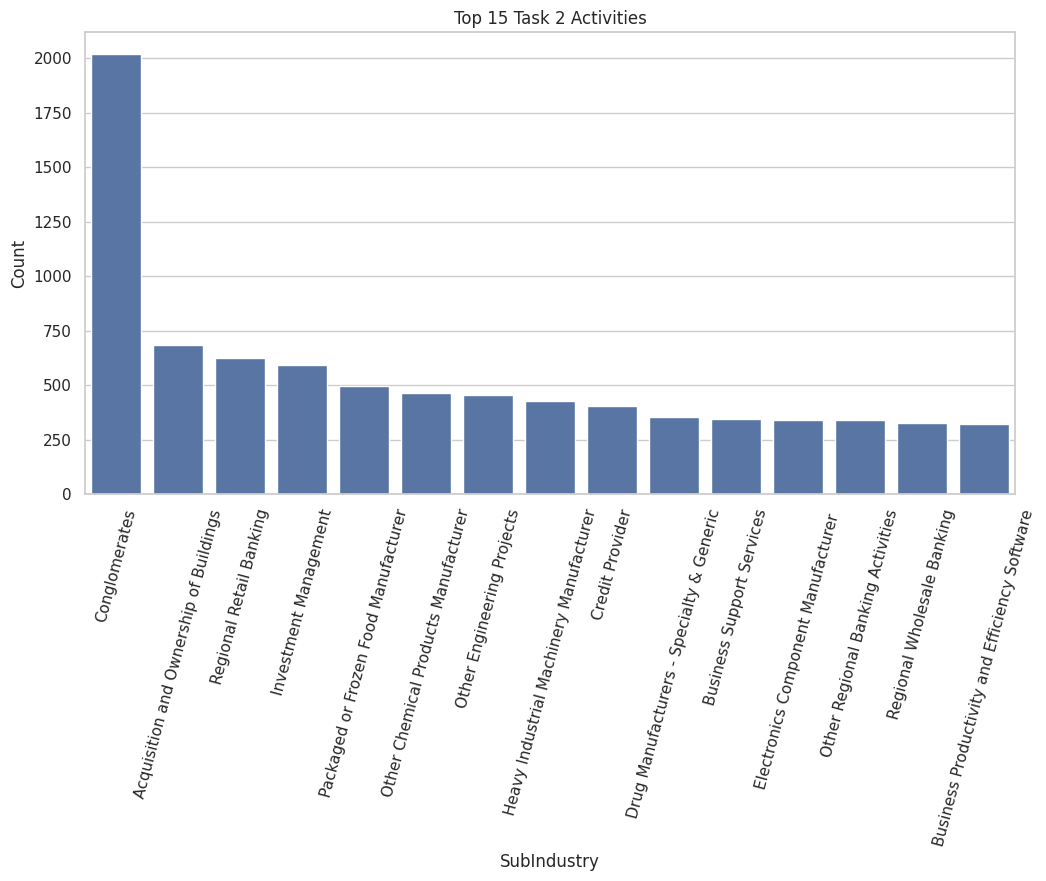

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(data=task2_class_dist.head(15), x="SubIndustry", y="Count")
plt.title("Top 15 Task 2 Activities")
plt.xticks(rotation=75)
plt.show()


In [32]:
task1_export["LongProfile_length"] = task1_export["LongProfile"].fillna("").str.len()
task1_export["SegmentDescription_length"] = task1_export["SegmentDescription"].fillna("").str.len()
task1_export["Combined_Text_length"] = task1_export["Combined_Text"].fillna("").str.len()

task2_export["SegmentDescription_length"] = task2_export["SegmentDescription"].fillna("").str.len()
task2_export["Combined_Text_length"] = task2_export["Combined_Text"].fillna("").str.len()



In [33]:
print("Task 1 text lengths")
display(task1_export[["LongProfile_length", "SegmentDescription_length", "Combined_Text_length"]].describe())

print("Task 2 text lengths")
display(task2_export[["SegmentDescription_length", "Combined_Text_length"]].describe())


Task 1 text lengths


,LongProfile_length,SegmentDescription_length,Combined_Text_length
count,53585.000000,53585.000000,53585.000000
mean,514.260203,101.485864,638.711505
std,185.115092,136.261807,253.652887
min,31.000000,0.000000,46.000000
25%,377.000000,0.000000,450.000000
50%,529.000000,0.000000,634.000000
75%,671.000000,166.000000,809.000000
max,812.000000,520.000000,1374.000000


Task 2 text lengths


,SegmentDescription_length,Combined_Text_length
count,27537.000000,27537.000000
mean,208.638269,228.994698
std,125.465420,127.247200
min,22.000000,28.000000
25%,110.000000,129.000000
50%,170.000000,192.000000
75%,281.000000,304.000000
max,520.000000,603.000000


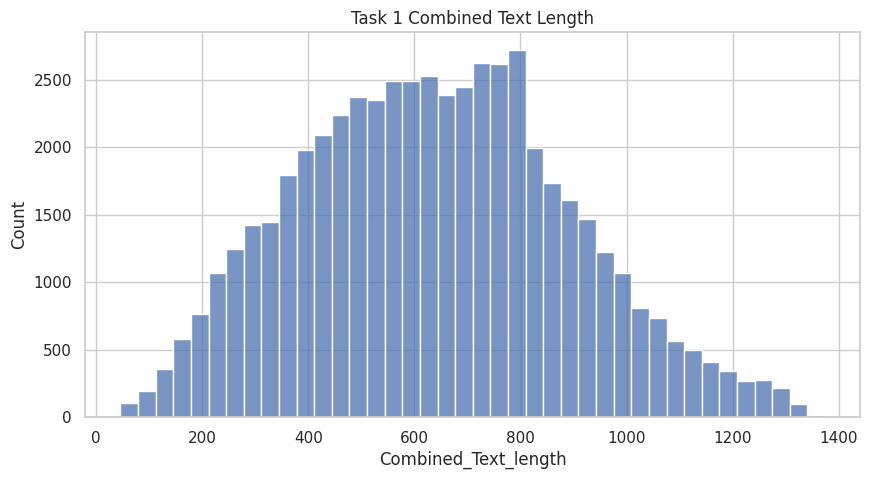

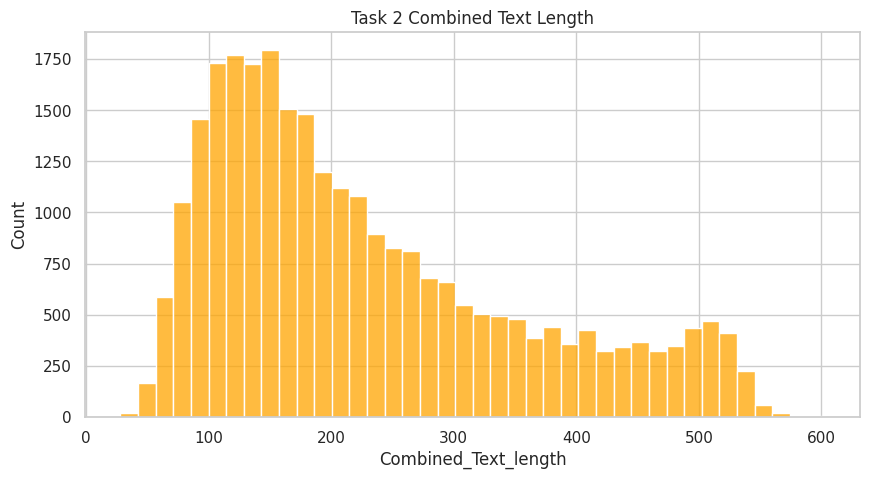

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(task1_export["Combined_Text_length"], bins=40)
plt.title("Task 1 Combined Text Length")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(task2_export["Combined_Text_length"], bins=40, color="orange")
plt.title("Task 2 Combined Text Length")
plt.show()


In [35]:
segment_count_summary = task1_export["SegmentCount"].describe()
segment_count_summary


,SegmentCount
count,53585.000000
mean,3.579229
std,2.555621
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,32.000000


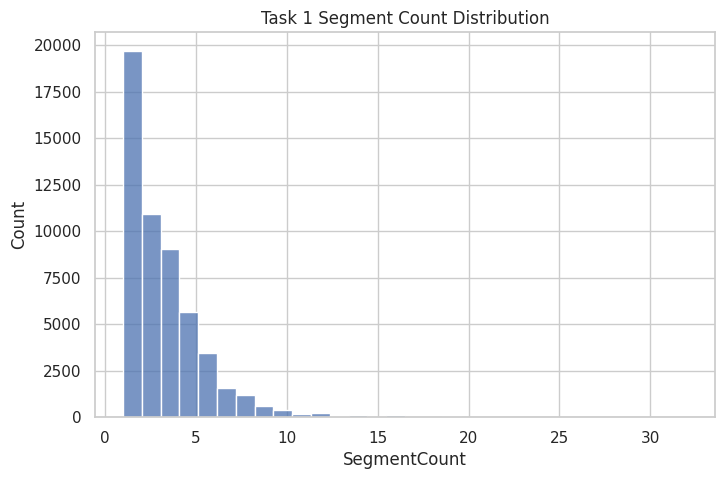

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(task1_export["SegmentCount"], bins=30)
plt.title("Task 1 Segment Count Distribution")
plt.xlabel("SegmentCount")
plt.show()


In [37]:
task1_export[["Revenue", "total_revenue_company_as_of", "revenue_share"]].describe()


,Revenue,total_revenue_company_as_of,revenue_share
count,5.358500e+04,5.358500e+04,53585.000000
mean,6.983377e+13,2.097876e+14,0.433088
std,1.046236e+16,2.784890e+16,0.841642
min,-4.139714e+12,-4.376729e+09,-107.175403
25%,6.591468e+07,3.650180e+08,0.083100
50%,6.990010e+08,3.435000e+09,0.309435
75%,7.045047e+09,3.272200e+10,0.859270
max,1.796362e+18,3.722006e+18,107.175403


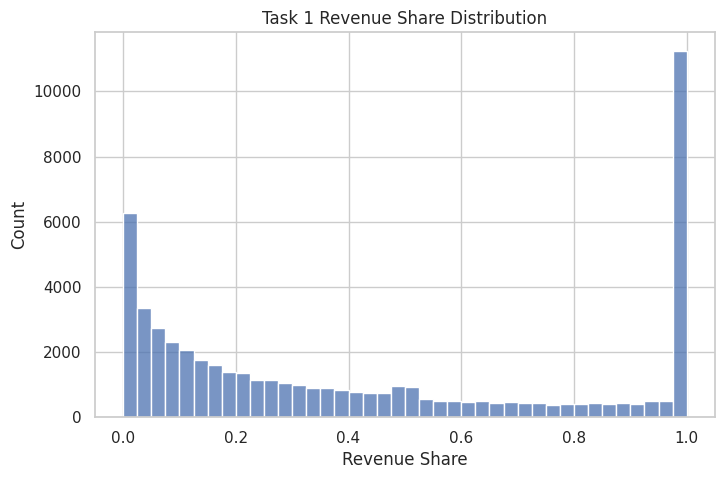

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(task1_export[task1_export["revenue_share"].between(0, 1)]["revenue_share"], bins=40)
plt.title("Task 1 Revenue Share Distribution")
plt.xlabel("Revenue Share")
plt.show()


In [39]:
task1_export["Is_Canonical_CompanyDate_Row"].value_counts()


,count
Is_Canonical_CompanyDate_Row,
False,30378
True,23207


In [40]:
canonical_summary = task1_export.groupby("Is_Canonical_CompanyDate_Row")[["Revenue", "revenue_share", "SegmentCount"]].mean()
canonical_summary


,Revenue,revenue_share,SegmentCount
Is_Canonical_CompanyDate_Row,,,
False,6.357494e+13,0.135060,4.549608
True,7.802658e+13,0.823207,2.309002


In [41]:
task1_export["has_multiple_row_labels"].value_counts()


,count
has_multiple_row_labels,
True,29554
False,24031


In [42]:
multi_label_summary = task1_export.groupby("has_multiple_row_labels")[["SegmentCount", "revenue_share"]].mean()
multi_label_summary


,SegmentCount,revenue_share
has_multiple_row_labels,,
False,2.578295,0.626566
True,4.393111,0.275766


In [43]:
task1_top10_share = task1_class_dist.head(10)["Count"].sum() / task1_class_dist["Count"].sum()
task2_top10_share = task2_class_dist.head(10)["Count"].sum() / task2_class_dist["Count"].sum()

print("Task 1 top 10 classes share:", round(task1_top10_share * 100, 2), "%")
print("Task 2 top 10 classes share:", round(task2_top10_share * 100, 2), "%")


Task 1 top 10 classes share: 29.35 %
Task 2 top 10 classes share: 23.65 %


## Baseline and Improved Text Models

This section moves from descriptive analytics into baseline modeling for both Task 1 and Task 2.


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


### Task 2 modeling table and filtered split

Task 2 contains some extremely rare classes. We remove classes with fewer than 2 rows before stratified splitting.


In [45]:
model_data_task2 = task2_export[[
    "CompanyId",
    "AsOfDate",
    "Combined_Text",
    "SubIndustry",
    "SubIndustryCode",
    "ParentIndustryName"
]].copy()

task2_class_counts = model_data_task2["SubIndustry"].value_counts()
top20_task2_classes = task2_class_counts.head(20).index
model_data_task2_top20 = model_data_task2[
    model_data_task2["SubIndustry"].isin(top20_task2_classes)
].copy()

train_df_task2, test_df_task2 = train_test_split(
    model_data_task2_top20,
    test_size=0.2,
    random_state=42,
    stratify=model_data_task2_top20["SubIndustry"]
)

print("Original Task 2 rows:", len(model_data_task2))
print("Task 2 top-20 rows:", len(model_data_task2_top20))
print("Original Task 2 classes:", model_data_task2["SubIndustry"].nunique())
print("Task 2 top-20 classes:", model_data_task2_top20["SubIndustry"].nunique())
print("Task 2 top-20 train shape:", train_df_task2.shape)
print("Task 2 top-20 test shape:", test_df_task2.shape)
print("Task 2 company overlap:", len(set(train_df_task2["CompanyId"]).intersection(set(test_df_task2["CompanyId"]))))


Original Task 2 rows: 27537
Task 2 top-20 rows: 9547
Original Task 2 classes: 428
Task 2 top-20 classes: 20
Task 2 top-20 train shape: (7637, 6)
Task 2 top-20 test shape: (1910, 6)
Task 2 company overlap: 1076


### Task 1: TF-IDF + Logistic Regression


In [46]:
task1_log_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english", min_df=2)),
    ("clf", LogisticRegression(max_iter=1500, class_weight="balanced", C=2.0))
])

task1_log_model.fit(train_df["Combined_Text"], train_df["MstarGlobal"])
task1_log_preds = task1_log_model.predict(test_df["Combined_Text"])

task1_log_accuracy = accuracy_score(test_df["MstarGlobal"], task1_log_preds)
task1_log_macro_f1 = f1_score(test_df["MstarGlobal"], task1_log_preds, average="macro")

print("Task 1 Logistic Accuracy:", round(task1_log_accuracy, 4))
print("Task 1 Logistic Macro F1:", round(task1_log_macro_f1, 4))


Task 1 Logistic Accuracy: 0.8291
Task 1 Logistic Macro F1: 0.8032


In [47]:
task1_log_report = pd.DataFrame(classification_report(test_df["MstarGlobal"], task1_log_preds, output_dict=True)).transpose()
display(task1_log_report.head(15))


,precision,recall,f1-score,support
Asset Management,0.967213,0.951613,0.959350,248.0
Auto Parts,0.858824,0.890244,0.874251,82.0
Banks - Regional,0.990741,0.977169,0.983908,219.0
Biotechnology,0.889655,0.837662,0.862876,154.0
Chemicals,0.545455,0.620690,0.580645,58.0
Drug Manufacturers - Specialty & Generic,0.826446,0.806452,0.816327,124.0
Electrical Equipment & Parts,0.762500,0.824324,0.792208,74.0
Electronic Components,0.833333,0.759494,0.794702,79.0
Engineering & Construction,0.847458,0.917431,0.881057,109.0
Information Technology Services,0.654762,0.723684,0.687500,76.0


### Task 1: TF-IDF + Linear SVM


In [48]:
task1_svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=25000, ngram_range=(1, 2), stop_words="english", min_df=2)),
    ("clf", LinearSVC(C=1.0, class_weight="balanced"))
])

task1_svm_model.fit(train_df["Combined_Text"], train_df["MstarGlobal"])
task1_svm_preds = task1_svm_model.predict(test_df["Combined_Text"])

task1_svm_accuracy = accuracy_score(test_df["MstarGlobal"], task1_svm_preds)
task1_svm_macro_f1 = f1_score(test_df["MstarGlobal"], task1_svm_preds, average="macro")

print("Task 1 LinearSVC Accuracy:", round(task1_svm_accuracy, 4))
print("Task 1 LinearSVC Macro F1:", round(task1_svm_macro_f1, 4))


Task 1 LinearSVC Accuracy: 0.8281
Task 1 LinearSVC Macro F1: 0.802


### Task 2: TF-IDF + Logistic Regression


In [49]:
task2_log_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english", min_df=2)),
    ("clf", LogisticRegression(max_iter=1500, class_weight="balanced", C=2.0))
])

task2_log_model.fit(train_df_task2["Combined_Text"], train_df_task2["SubIndustry"])
task2_log_preds = task2_log_model.predict(test_df_task2["Combined_Text"])

task2_log_accuracy = accuracy_score(test_df_task2["SubIndustry"], task2_log_preds)
task2_log_macro_f1 = f1_score(test_df_task2["SubIndustry"], task2_log_preds, average="macro")

print("Task 2 Logistic Accuracy:", round(task2_log_accuracy, 4))
print("Task 2 Logistic Macro F1:", round(task2_log_macro_f1, 4))


Task 2 Logistic Accuracy: 0.7157
Task 2 Logistic Macro F1: 0.7183


In [50]:
task2_log_report = pd.DataFrame(classification_report(test_df_task2["SubIndustry"], task2_log_preds, output_dict=True)).transpose()
display(task2_log_report.head(15))


,precision,recall,f1-score,support
Acquisition and Ownership of Buildings,0.776978,0.794118,0.785455,136.0
Automotive Parts Manufacturer,0.727273,0.774194,0.750000,62.0
Brokerage Services,0.750000,0.857143,0.800000,56.0
Business Productivity and Efficiency Software,0.460674,0.630769,0.532468,65.0
Business Support Services,0.400000,0.521739,0.452830,69.0
Conglomerates,0.786822,0.502475,0.613293,404.0
Credit Provider,0.673913,0.765432,0.716763,81.0
Development of Non Residential Buildings,0.557377,0.723404,0.629630,47.0
Drug Manufacturers - Specialty & Generic,0.753425,0.774648,0.763889,71.0
Electronics Component Manufacturer,0.701493,0.691176,0.696296,68.0


### Task 2: TF-IDF + Linear SVM


In [51]:
task2_svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=25000, ngram_range=(1, 2), stop_words="english", min_df=2)),
    ("clf", LinearSVC(C=1.0, class_weight="balanced"))
])

task2_svm_model.fit(train_df_task2["Combined_Text"], train_df_task2["SubIndustry"])
task2_svm_preds = task2_svm_model.predict(test_df_task2["Combined_Text"])

task2_svm_accuracy = accuracy_score(test_df_task2["SubIndustry"], task2_svm_preds)
task2_svm_macro_f1 = f1_score(test_df_task2["SubIndustry"], task2_svm_preds, average="macro")

print("Task 2 LinearSVC Accuracy:", round(task2_svm_accuracy, 4))
print("Task 2 LinearSVC Macro F1:", round(task2_svm_macro_f1, 4))


Task 2 LinearSVC Accuracy: 0.7366
Task 2 LinearSVC Macro F1: 0.7337


### Model comparison summary


In [52]:
model_comparison = pd.DataFrame([
    {"Task": "Task 1", "Scope": "Top 20 classes", "Model": "TF-IDF + Logistic Regression", "Accuracy": round(task1_log_accuracy, 4), "Macro_F1": round(task1_log_macro_f1, 4)},
    {"Task": "Task 1", "Scope": "Top 20 classes", "Model": "TF-IDF + LinearSVC", "Accuracy": round(task1_svm_accuracy, 4), "Macro_F1": round(task1_svm_macro_f1, 4)},
    {"Task": "Task 2", "Scope": "Top 20 classes", "Model": "TF-IDF + Logistic Regression", "Accuracy": round(task2_log_accuracy, 4), "Macro_F1": round(task2_log_macro_f1, 4)},
    {"Task": "Task 2", "Scope": "Top 20 classes", "Model": "TF-IDF + LinearSVC", "Accuracy": round(task2_svm_accuracy, 4), "Macro_F1": round(task2_svm_macro_f1, 4)}
])

model_comparison


,Task,Scope,Model,Accuracy,Macro_F1
0,Task 1,Top 20 classes,TF-IDF + Logistic Regression,0.8291,0.8032
1,Task 1,Top 20 classes,TF-IDF + LinearSVC,0.8281,0.8020
2,Task 2,Top 20 classes,TF-IDF + Logistic Regression,0.7157,0.7183
3,Task 2,Top 20 classes,TF-IDF + LinearSVC,0.7366,0.7337


## Advanced Models: Sentence-BERT Embeddings

This section moves beyond the TF-IDF baselines. We generate semantic text embeddings using a Sentence-BERT model and then train a simple classifier on top. This gives us a stronger meaning-based comparison for both Task 1 and Task 2 while keeping the workflow structured and easy to compare with the baseline models.


In [53]:
# Run this in Colab if sentence-transformers is not installed
# !pip install sentence-transformers


In [54]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Loaded embedding model: all-MiniLM-L6-v2")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded embedding model: all-MiniLM-L6-v2


In [55]:
def encode_texts(model, texts, batch_size=64):
    return model.encode(
        texts.tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True
    )


### Task 1: Sentence-BERT Embeddings + Logistic Regression


In [56]:
X_train_task1_emb = encode_texts(embedding_model, train_df["Combined_Text"])
X_test_task1_emb = encode_texts(embedding_model, test_df["Combined_Text"])

task1_emb_model = LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0)
task1_emb_model.fit(X_train_task1_emb, train_df["MstarGlobal"])
task1_emb_preds = task1_emb_model.predict(X_test_task1_emb)

task1_emb_accuracy = accuracy_score(test_df["MstarGlobal"], task1_emb_preds)
task1_emb_macro_f1 = f1_score(test_df["MstarGlobal"], task1_emb_preds, average="macro")

print("Task 1 Embedding + Logistic Accuracy:", round(task1_emb_accuracy, 4))
print("Task 1 Embedding + Logistic Macro F1:", round(task1_emb_macro_f1, 4))


Batches:   0%|          | 0/131 [00:00<?, ?it/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

Task 1 Embedding + Logistic Accuracy: 0.8095
Task 1 Embedding + Logistic Macro F1: 0.7812


In [57]:
task1_emb_report = pd.DataFrame(
    classification_report(test_df["MstarGlobal"], task1_emb_preds, output_dict=True)
).transpose()
display(task1_emb_report.head(15))


,precision,recall,f1-score,support
Asset Management,0.966805,0.939516,0.952965,248.0
Auto Parts,0.795455,0.853659,0.823529,82.0
Banks - Regional,0.981651,0.977169,0.979405,219.0
Biotechnology,0.909091,0.779221,0.839161,154.0
Chemicals,0.514286,0.620690,0.562500,58.0
Drug Manufacturers - Specialty & Generic,0.791045,0.854839,0.821705,124.0
Electrical Equipment & Parts,0.655172,0.770270,0.708075,74.0
Electronic Components,0.753247,0.734177,0.743590,79.0
Engineering & Construction,0.837838,0.853211,0.845455,109.0
Information Technology Services,0.702703,0.684211,0.693333,76.0


### Task 2: Sentence-BERT Embeddings + LinearSVC


In [58]:
X_train_task2_emb = encode_texts(embedding_model, train_df_task2["Combined_Text"])
X_test_task2_emb = encode_texts(embedding_model, test_df_task2["Combined_Text"])

task2_emb_model = LinearSVC(C=1.0, class_weight="balanced")
task2_emb_model.fit(X_train_task2_emb, train_df_task2["SubIndustry"])
task2_emb_preds = task2_emb_model.predict(X_test_task2_emb)

task2_emb_accuracy = accuracy_score(test_df_task2["SubIndustry"], task2_emb_preds)
task2_emb_macro_f1 = f1_score(test_df_task2["SubIndustry"], task2_emb_preds, average="macro")

print("Task 2 Embedding + LinearSVC Accuracy:", round(task2_emb_accuracy, 4))
print("Task 2 Embedding + LinearSVC Macro F1:", round(task2_emb_macro_f1, 4))


Batches:   0%|          | 0/120 [00:00<?, ?it/s]

Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Task 2 Embedding + LinearSVC Accuracy: 0.7188
Task 2 Embedding + LinearSVC Macro F1: 0.7117


In [59]:
task2_emb_report = pd.DataFrame(
    classification_report(test_df_task2["SubIndustry"], task2_emb_preds, output_dict=True)
).transpose()
display(task2_emb_report.head(15))


,precision,recall,f1-score,support
Acquisition and Ownership of Buildings,0.788732,0.823529,0.805755,136.0
Automotive Parts Manufacturer,0.746479,0.854839,0.796992,62.0
Brokerage Services,0.686567,0.821429,0.747967,56.0
Business Productivity and Efficiency Software,0.513158,0.600000,0.553191,65.0
Business Support Services,0.328767,0.347826,0.338028,69.0
Conglomerates,0.837638,0.561881,0.672593,404.0
Credit Provider,0.693182,0.753086,0.721893,81.0
Development of Non Residential Buildings,0.634615,0.702128,0.666667,47.0
Drug Manufacturers - Specialty & Generic,0.802632,0.859155,0.829932,71.0
Electronics Component Manufacturer,0.607143,0.750000,0.671053,68.0


### Advanced model comparison


In [60]:
advanced_model_comparison = pd.DataFrame([
    {"Task": "Task 1", "Scope": "Top 20 classes", "Model": "Sentence-BERT + Logistic Regression", "Accuracy": round(task1_emb_accuracy, 4), "Macro_F1": round(task1_emb_macro_f1, 4)},
    {"Task": "Task 2", "Scope": "Top 20 classes", "Model": "Sentence-BERT + LinearSVC", "Accuracy": round(task2_emb_accuracy, 4), "Macro_F1": round(task2_emb_macro_f1, 4)}
])

full_model_comparison = pd.concat([model_comparison, advanced_model_comparison], ignore_index=True)
full_model_comparison


,Task,Scope,Model,Accuracy,Macro_F1
0,Task 1,Top 20 classes,TF-IDF + Logistic Regression,0.8291,0.8032
1,Task 1,Top 20 classes,TF-IDF + LinearSVC,0.8281,0.8020
2,Task 2,Top 20 classes,TF-IDF + Logistic Regression,0.7157,0.7183
3,Task 2,Top 20 classes,TF-IDF + LinearSVC,0.7366,0.7337
4,Task 1,Top 20 classes,Sentence-BERT + Logistic Regression,0.8095,0.7812
5,Task 2,Top 20 classes,Sentence-BERT + LinearSVC,0.7188,0.7117


## Model Tuning for Top 20 Classes

Since TF-IDF + LinearSVC is currently the strongest model family, this section fine-tunes that setup for both tasks using a small grid over the most important parameters. The tuning is done only on the top-20 modeling scope so it stays consistent with the rest of the predictive analysis.


In [61]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold


### Task 1: Tuned TF-IDF + LinearSVC


In [62]:
task1_tune_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LinearSVC(class_weight="balanced"))
])

task1_param_grid = {
    "tfidf__max_features": [15000, 25000, 30000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],
    "clf__C": [0.5, 1.0, 2.0]
}

task1_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

task1_grid = GridSearchCV(
    estimator=task1_tune_pipeline,
    param_grid=task1_param_grid,
    scoring="f1_macro",
    cv=task1_cv,
    n_jobs=-1,
    verbose=1
)

task1_grid.fit(train_df["Combined_Text"], train_df["MstarGlobal"])

task1_tuned_model = task1_grid.best_estimator_
task1_tuned_preds = task1_tuned_model.predict(test_df["Combined_Text"])

task1_tuned_accuracy = accuracy_score(test_df["MstarGlobal"], task1_tuned_preds)
task1_tuned_macro_f1 = f1_score(test_df["MstarGlobal"], task1_tuned_preds, average="macro")

print("Task 1 best params:", task1_grid.best_params_)
print("Task 1 tuned Accuracy:", round(task1_tuned_accuracy, 4))
print("Task 1 tuned Macro F1:", round(task1_tuned_macro_f1, 4))


Fitting 3 folds for each of 144 candidates, totalling 432 fits
Task 1 best params: {'clf__C': 0.5, 'tfidf__max_df': 0.95, 'tfidf__max_features': 25000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False}
Task 1 tuned Accuracy: 0.832
Task 1 tuned Macro F1: 0.8049


In [63]:
task1_tuned_report = pd.DataFrame(
    classification_report(test_df["MstarGlobal"], task1_tuned_preds, output_dict=True)
).transpose()
display(task1_tuned_report.head(15))


,precision,recall,f1-score,support
Asset Management,0.956175,0.967742,0.961924,248.0
Auto Parts,0.879518,0.890244,0.884848,82.0
Banks - Regional,0.990826,0.986301,0.988558,219.0
Biotechnology,0.867550,0.850649,0.859016,154.0
Chemicals,0.557377,0.586207,0.571429,58.0
Drug Manufacturers - Specialty & Generic,0.846154,0.798387,0.821577,124.0
Electrical Equipment & Parts,0.765432,0.837838,0.800000,74.0
Electronic Components,0.821918,0.759494,0.789474,79.0
Engineering & Construction,0.822581,0.935780,0.875536,109.0
Information Technology Services,0.621951,0.671053,0.645570,76.0


### Task 2: Tuned TF-IDF + LinearSVC


In [64]:
task2_tune_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LinearSVC(class_weight="balanced"))
])

task2_param_grid = {
    "tfidf__max_features": [15000, 25000, 30000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],
    "clf__C": [0.5, 1.0, 2.0]
}

task2_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

task2_grid = GridSearchCV(
    estimator=task2_tune_pipeline,
    param_grid=task2_param_grid,
    scoring="f1_macro",
    cv=task2_cv,
    n_jobs=-1,
    verbose=1
)

task2_grid.fit(train_df_task2["Combined_Text"], train_df_task2["SubIndustry"])

task2_tuned_model = task2_grid.best_estimator_
task2_tuned_preds = task2_tuned_model.predict(test_df_task2["Combined_Text"])

task2_tuned_accuracy = accuracy_score(test_df_task2["SubIndustry"], task2_tuned_preds)
task2_tuned_macro_f1 = f1_score(test_df_task2["SubIndustry"], task2_tuned_preds, average="macro")

print("Task 2 best params:", task2_grid.best_params_)
print("Task 2 tuned Accuracy:", round(task2_tuned_accuracy, 4))
print("Task 2 tuned Macro F1:", round(task2_tuned_macro_f1, 4))


Fitting 3 folds for each of 144 candidates, totalling 432 fits
Task 2 best params: {'clf__C': 2.0, 'tfidf__max_df': 0.95, 'tfidf__max_features': 30000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Task 2 tuned Accuracy: 0.7398
Task 2 tuned Macro F1: 0.733


In [65]:
task2_tuned_report = pd.DataFrame(
    classification_report(test_df_task2["SubIndustry"], task2_tuned_preds, output_dict=True)
).transpose()
display(task2_tuned_report.head(15))


,precision,recall,f1-score,support
Acquisition and Ownership of Buildings,0.733333,0.808824,0.769231,136.0
Automotive Parts Manufacturer,0.783333,0.758065,0.770492,62.0
Brokerage Services,0.824561,0.839286,0.831858,56.0
Business Productivity and Efficiency Software,0.540541,0.615385,0.575540,65.0
Business Support Services,0.491228,0.405797,0.444444,69.0
Conglomerates,0.740000,0.641089,0.687003,404.0
Credit Provider,0.738095,0.765432,0.751515,81.0
Development of Non Residential Buildings,0.553571,0.659574,0.601942,47.0
Drug Manufacturers - Specialty & Generic,0.780822,0.802817,0.791667,71.0
Electronics Component Manufacturer,0.727273,0.705882,0.716418,68.0


### Tuned model comparison


In [66]:
tuned_model_comparison = pd.DataFrame([
    {"Task": "Task 1", "Scope": "Top 20 classes", "Model": "Tuned TF-IDF + LinearSVC", "Accuracy": round(task1_tuned_accuracy, 4), "Macro_F1": round(task1_tuned_macro_f1, 4)},
    {"Task": "Task 2", "Scope": "Top 20 classes", "Model": "Tuned TF-IDF + LinearSVC", "Accuracy": round(task2_tuned_accuracy, 4), "Macro_F1": round(task2_tuned_macro_f1, 4)}
])

all_model_comparison = pd.concat([full_model_comparison, tuned_model_comparison], ignore_index=True)
all_model_comparison


,Task,Scope,Model,Accuracy,Macro_F1
0,Task 1,Top 20 classes,TF-IDF + Logistic Regression,0.8291,0.8032
1,Task 1,Top 20 classes,TF-IDF + LinearSVC,0.8281,0.8020
2,Task 2,Top 20 classes,TF-IDF + Logistic Regression,0.7157,0.7183
3,Task 2,Top 20 classes,TF-IDF + LinearSVC,0.7366,0.7337
4,Task 1,Top 20 classes,Sentence-BERT + Logistic Regression,0.8095,0.7812
5,Task 2,Top 20 classes,Sentence-BERT + LinearSVC,0.7188,0.7117
6,Task 1,Top 20 classes,Tuned TF-IDF + LinearSVC,0.8320,0.8049
7,Task 2,Top 20 classes,Tuned TF-IDF + LinearSVC,0.7398,0.7330


## Additional Model Options

This section adds a few broader model directions beyond the main baseline and tuning sections. Some of these are lightweight and practical, while the transformer section is a heavier optional benchmark.


### 1. Multinomial Naive Bayes


In [67]:
from sklearn.naive_bayes import MultinomialNB

task1_nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english", min_df=2)),
    ("clf", MultinomialNB())
])

task1_nb_model.fit(train_df["Combined_Text"], train_df["MstarGlobal"])
task1_nb_preds = task1_nb_model.predict(test_df["Combined_Text"])
task1_nb_accuracy = accuracy_score(test_df["MstarGlobal"], task1_nb_preds)
task1_nb_macro_f1 = f1_score(test_df["MstarGlobal"], task1_nb_preds, average="macro")

task2_nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english", min_df=2)),
    ("clf", MultinomialNB())
])

task2_nb_model.fit(train_df_task2["Combined_Text"], train_df_task2["SubIndustry"])
task2_nb_preds = task2_nb_model.predict(test_df_task2["Combined_Text"])
task2_nb_accuracy = accuracy_score(test_df_task2["SubIndustry"], task2_nb_preds)
task2_nb_macro_f1 = f1_score(test_df_task2["SubIndustry"], task2_nb_preds, average="macro")

print("Task 1 Naive Bayes Accuracy:", round(task1_nb_accuracy, 4))
print("Task 1 Naive Bayes Macro F1:", round(task1_nb_macro_f1, 4))
print("Task 2 Naive Bayes Accuracy:", round(task2_nb_accuracy, 4))
print("Task 2 Naive Bayes Macro F1:", round(task2_nb_macro_f1, 4))


Task 1 Naive Bayes Accuracy: 0.752
Task 1 Naive Bayes Macro F1: 0.6986
Task 2 Naive Bayes Accuracy: 0.4576
Task 2 Naive Bayes Macro F1: 0.3554


### 2. Simple Ensemble Voting


In [68]:
from collections import Counter
import numpy as np

def majority_vote(*pred_arrays):
    stacked = np.vstack(pred_arrays).T
    return np.array([Counter(row).most_common(1)[0][0] for row in stacked])

task1_pred_list = [task1_log_preds, task1_svm_preds, task1_tuned_preds]
if "task1_emb_preds" in globals():
    task1_pred_list.append(task1_emb_preds)

task2_pred_list = [task2_log_preds, task2_svm_preds, task2_tuned_preds]
if "task2_emb_preds" in globals():
    task2_pred_list.append(task2_emb_preds)

task1_ensemble_preds = majority_vote(*task1_pred_list)
task1_ensemble_accuracy = accuracy_score(test_df["MstarGlobal"], task1_ensemble_preds)
task1_ensemble_macro_f1 = f1_score(test_df["MstarGlobal"], task1_ensemble_preds, average="macro")

task2_ensemble_preds = majority_vote(*task2_pred_list)
task2_ensemble_accuracy = accuracy_score(test_df_task2["SubIndustry"], task2_ensemble_preds)
task2_ensemble_macro_f1 = f1_score(test_df_task2["SubIndustry"], task2_ensemble_preds, average="macro")

print("Task 1 ensemble models used:", len(task1_pred_list))
print("Task 2 ensemble models used:", len(task2_pred_list))
print("Task 1 Ensemble Accuracy:", round(task1_ensemble_accuracy, 4))
print("Task 1 Ensemble Macro F1:", round(task1_ensemble_macro_f1, 4))
print("Task 2 Ensemble Accuracy:", round(task2_ensemble_accuracy, 4))
print("Task 2 Ensemble Macro F1:", round(task2_ensemble_macro_f1, 4))


Task 1 ensemble models used: 4
Task 2 ensemble models used: 4
Task 1 Ensemble Accuracy: 0.8296
Task 1 Ensemble Macro F1: 0.8023
Task 2 Ensemble Accuracy: 0.7346
Task 2 Ensemble Macro F1: 0.7337


### 3. Hierarchical classification for Task 2

This version predicts the parent industry first and then predicts the detailed `SubIndustry` only within that parent. That makes the structure match the GECS hierarchy more closely.


In [69]:
task2_hier_train = train_df_task2.copy()
task2_hier_test = test_df_task2.copy()

if "ParentIndustryName" not in task2_hier_train.columns or "ParentIndustryName" not in task2_hier_test.columns:
    raise KeyError("ParentIndustryName is missing from the Task 2 modeling tables. Rerun the Task 2 modeling prep cell first.")

parent_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=25000, ngram_range=(1, 2), stop_words="english", min_df=2)),
    ("clf", LinearSVC(C=1.0, class_weight="balanced"))
])
parent_model.fit(task2_hier_train["Combined_Text"], task2_hier_train["ParentIndustryName"])
predicted_parents = parent_model.predict(task2_hier_test["Combined_Text"])

child_models = {}
fallback_label = task2_hier_train["SubIndustry"].mode().iloc[0]

for parent_name, group in task2_hier_train.groupby("ParentIndustryName"):
    if group["SubIndustry"].nunique() < 2:
        child_models[parent_name] = group["SubIndustry"].iloc[0]
    else:
        local_model = Pipeline([
            ("tfidf", TfidfVectorizer(max_features=15000, ngram_range=(1, 2), stop_words="english", min_df=1)),
            ("clf", LinearSVC(C=1.0, class_weight="balanced"))
        ])
        local_model.fit(group["Combined_Text"], group["SubIndustry"])
        child_models[parent_name] = local_model

task2_hier_preds = []
for text, parent_name in zip(task2_hier_test["Combined_Text"], predicted_parents):
    child_model = child_models.get(parent_name)
    if child_model is None:
        task2_hier_preds.append(fallback_label)
    elif isinstance(child_model, str):
        task2_hier_preds.append(child_model)
    else:
        task2_hier_preds.append(child_model.predict([text])[0])

task2_hier_accuracy = accuracy_score(task2_hier_test["SubIndustry"], task2_hier_preds)
task2_hier_macro_f1 = f1_score(task2_hier_test["SubIndustry"], task2_hier_preds, average="macro")

print("Task 2 Hierarchical Accuracy:", round(task2_hier_accuracy, 4))
print("Task 2 Hierarchical Macro F1:", round(task2_hier_macro_f1, 4))


Task 2 Hierarchical Accuracy: 0.7382
Task 2 Hierarchical Macro F1: 0.7339


### 4. Optional Transformer fine-tuning

This is a heavier advanced benchmark. It is optional because it needs extra packages and takes longer to run. The code below is set up for both tasks using a compact transformer model so you can compare it with the TF-IDF and embedding results.


In [70]:
# Run this if transformers and datasets are not installed
# !pip install transformers datasets accelerate


In [71]:
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

transformer_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(transformer_checkpoint)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

def build_hf_dataset(df, text_col, label_col, encoder=None):
    temp = df[[text_col, label_col]].copy()
    temp.columns = ["text", "label_name"]
    if encoder is None:
        encoder = LabelEncoder()
        temp["label"] = encoder.fit_transform(temp["label_name"])
    else:
        temp["label"] = encoder.transform(temp["label_name"])
    ds = Dataset.from_pandas(temp[["text", "label"]], preserve_index=False)
    ds = ds.map(tokenize_batch, batched=True)
    ds = ds.rename_column("label", "labels")
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds, encoder

def compute_metrics_fn(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [73]:
# Task 1 transformer
task1_train_ds, task1_label_encoder = build_hf_dataset(
    train_df, "Combined_Text", "MstarGlobal"
)
task1_test_ds, _ = build_hf_dataset(
    test_df, "Combined_Text", "MstarGlobal", encoder=task1_label_encoder
)

task1_transformer_model = AutoModelForSequenceClassification.from_pretrained(
    transformer_checkpoint,
    num_labels=len(task1_label_encoder.classes_)
)

task1_args = TrainingArguments(
    output_dir="./task1_transformer_output",
    eval_strategy="epoch",          # changed from evaluation_strategy
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

task1_trainer = Trainer(
    model=task1_transformer_model,
    args=task1_args,
    train_dataset=task1_train_ds,
    eval_dataset=task1_test_ds,
    compute_metrics=compute_metrics_fn
)

task1_trainer.train()
task1_transformer_metrics = task1_trainer.evaluate()
print(task1_transformer_metrics)



Map:   0%|          | 0/8354 [00:00<?, ? examples/s]

Map:   0%|          | 0/2089 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.620138,0.553958,0.826233,0.795141
2,0.433578,0.480254,0.849210,0.822794


{'eval_loss': 0.4802536368370056, 'eval_accuracy': 0.8492101483963619, 'eval_macro_f1': 0.8227943312693562, 'eval_runtime': 18.4902, 'eval_samples_per_second': 112.979, 'eval_steps_per_second': 14.17, 'epoch': 2.0}


In [74]:
# Task 2 transformer
task2_train_ds, task2_label_encoder = build_hf_dataset(
    train_df_task2, "Combined_Text", "SubIndustry"
)
task2_test_ds, _ = build_hf_dataset(
    test_df_task2, "Combined_Text", "SubIndustry", encoder=task2_label_encoder
)

task2_transformer_model = AutoModelForSequenceClassification.from_pretrained(
    transformer_checkpoint,
    num_labels=len(task2_label_encoder.classes_)
)

task2_args = TrainingArguments(
    output_dir="./task2_transformer_output",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

task2_trainer = Trainer(
    model=task2_transformer_model,
    args=task2_args,
    train_dataset=task2_train_ds,
    eval_dataset=task2_test_ds,
    compute_metrics=compute_metrics_fn
)

task2_trainer.train()
task2_transformer_metrics = task2_trainer.evaluate()
print(task2_transformer_metrics)



Map:   0%|          | 0/7637 [00:00<?, ? examples/s]

Map:   0%|          | 0/1910 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.905545,0.865400,0.737696,0.680337
2,0.615184,0.765816,0.772251,0.740357


{'eval_loss': 0.7658159732818604, 'eval_accuracy': 0.7722513089005235, 'eval_macro_f1': 0.7403568449694498, 'eval_runtime': 16.7475, 'eval_samples_per_second': 114.047, 'eval_steps_per_second': 14.271, 'epoch': 2.0}


### Extended model comparison


In [75]:
extended_model_comparison = pd.DataFrame([
    {"Task": "Task 1", "Scope": "Top 20 classes", "Model": "Multinomial Naive Bayes", "Accuracy": round(task1_nb_accuracy, 4), "Macro_F1": round(task1_nb_macro_f1, 4)},
    {"Task": "Task 2", "Scope": "Top 20 classes", "Model": "Multinomial Naive Bayes", "Accuracy": round(task2_nb_accuracy, 4), "Macro_F1": round(task2_nb_macro_f1, 4)},
    {"Task": "Task 1", "Scope": "Top 20 classes", "Model": "Ensemble Vote", "Accuracy": round(task1_ensemble_accuracy, 4), "Macro_F1": round(task1_ensemble_macro_f1, 4)},
    {"Task": "Task 2", "Scope": "Top 20 classes", "Model": "Ensemble Vote", "Accuracy": round(task2_ensemble_accuracy, 4), "Macro_F1": round(task2_ensemble_macro_f1, 4)},
    {"Task": "Task 2", "Scope": "Top 20 classes", "Model": "Hierarchical TF-IDF + LinearSVC", "Accuracy": round(task2_hier_accuracy, 4), "Macro_F1": round(task2_hier_macro_f1, 4)}
])

final_model_landscape = pd.concat([all_model_comparison, extended_model_comparison], ignore_index=True)
final_model_landscape


,Task,Scope,Model,Accuracy,Macro_F1
0,Task 1,Top 20 classes,TF-IDF + Logistic Regression,0.8291,0.8032
1,Task 1,Top 20 classes,TF-IDF + LinearSVC,0.8281,0.8020
2,Task 2,Top 20 classes,TF-IDF + Logistic Regression,0.7157,0.7183
3,Task 2,Top 20 classes,TF-IDF + LinearSVC,0.7366,0.7337
4,Task 1,Top 20 classes,Sentence-BERT + Logistic Regression,0.8095,0.7812
5,Task 2,Top 20 classes,Sentence-BERT + LinearSVC,0.7188,0.7117
6,Task 1,Top 20 classes,Tuned TF-IDF + LinearSVC,0.8320,0.8049
7,Task 2,Top 20 classes,Tuned TF-IDF + LinearSVC,0.7398,0.7330
8,Task 1,Top 20 classes,Multinomial Naive Bayes,0.7520,0.6986
9,Task 2,Top 20 classes,Multinomial Naive Bayes,0.4576,0.3554


In [76]:
# Optional: save modeling outputs
task1_log_report.to_csv("task1_logistic_classification_report.csv")
task2_log_report.to_csv("task2_logistic_classification_report.csv")
# model_comparison.to_csv("model_comparison_summary.csv", index=False)


In [77]:
task1_report = pd.read_csv("task1_logistic_classification_report.csv", index_col=0)
task2_report = pd.read_csv("task2_logistic_classification_report.csv", index_col=0)

print("Task 1 report shape:", task1_report.shape)
print("Task 2 report shape:", task2_report.shape)

display(task1_report.head())
display(task2_report.head())


Task 1 report shape: (23, 4)
Task 2 report shape: (23, 4)


,precision,recall,f1-score,support
Asset Management,0.967213,0.951613,0.959350,248.0
Auto Parts,0.858824,0.890244,0.874251,82.0
Banks - Regional,0.990741,0.977169,0.983908,219.0
Biotechnology,0.889655,0.837662,0.862876,154.0
Chemicals,0.545455,0.620690,0.580645,58.0


,precision,recall,f1-score,support
Acquisition and Ownership of Buildings,0.776978,0.794118,0.785455,136.0
Automotive Parts Manufacturer,0.727273,0.774194,0.750000,62.0
Brokerage Services,0.750000,0.857143,0.800000,56.0
Business Productivity and Efficiency Software,0.460674,0.630769,0.532468,65.0
Business Support Services,0.400000,0.521739,0.452830,69.0


In [78]:
task1_report_clean = task1_report.loc[
    ~task1_report.index.isin(["accuracy", "macro avg", "weighted avg"])
].copy()

task2_report_clean = task2_report.loc[
    ~task2_report.index.isin(["accuracy", "macro avg", "weighted avg"])
].copy()

print("Task 1 class rows:", task1_report_clean.shape)
print("Task 2 class rows:", task2_report_clean.shape)


Task 1 class rows: (20, 4)
Task 2 class rows: (20, 4)


In [79]:
print("Best Task 1 classes by F1")
display(task1_report_clean.sort_values("f1-score", ascending=False).head(15))

print("Best Task 2 classes by F1")
display(task2_report_clean.sort_values("f1-score", ascending=False).head(15))


Best Task 1 classes by F1


,precision,recall,f1-score,support
Banks - Regional,0.990741,0.977169,0.983908,219.0
Oil & Gas E&P,0.950000,0.982759,0.966102,58.0
Asset Management,0.967213,0.951613,0.959350,248.0
Packaged Foods,0.921569,0.912621,0.917073,103.0
Medical Devices,0.839080,0.948052,0.890244,77.0
Engineering & Construction,0.847458,0.917431,0.881057,109.0
Telecom Services,0.857143,0.905660,0.880734,53.0
Auto Parts,0.858824,0.890244,0.874251,82.0
Biotechnology,0.889655,0.837662,0.862876,154.0
Drug Manufacturers - Specialty & Generic,0.826446,0.806452,0.816327,124.0


Best Task 2 classes by F1


,precision,recall,f1-score,support
Packaged or Frozen Food Manufacturer,0.810345,0.949495,0.874419,99.0
Regional Retail Banking,0.891667,0.856000,0.873469,125.0
Regional Wholesale Banking,0.846154,0.846154,0.846154,65.0
Investment Management,0.827586,0.806723,0.817021,119.0
Brokerage Services,0.750000,0.857143,0.800000,56.0
Acquisition and Ownership of Buildings,0.776978,0.794118,0.785455,136.0
Logistics Support Activities,0.777778,0.792453,0.785047,53.0
Drug Manufacturers - Specialty & Generic,0.753425,0.774648,0.763889,71.0
Other Chemical Products Manufacturer,0.730000,0.784946,0.756477,93.0
Other Engineering Projects,0.704762,0.813187,0.755102,91.0


In [80]:
print("Worst Task 1 classes by F1")
display(task1_report_clean.sort_values("f1-score", ascending=True).head(15))

print("Worst Task 2 classes by F1")
display(task2_report_clean.sort_values("f1-score", ascending=True).head(15))


Worst Task 1 classes by F1


,precision,recall,f1-score,support
Specialty Chemicals,0.606061,0.481928,0.536913,83.0
Software - Infrastructure,0.597561,0.538462,0.566474,91.0
Chemicals,0.545455,0.620690,0.580645,58.0
Information Technology Services,0.654762,0.723684,0.687500,76.0
Software - Application,0.676259,0.728682,0.701493,129.0
Real Estate - Development,0.859375,0.705128,0.774648,78.0
Specialty Industrial Machinery,0.787037,0.794393,0.790698,107.0
Electrical Equipment & Parts,0.762500,0.824324,0.792208,74.0
Electronic Components,0.833333,0.759494,0.794702,79.0
Real Estate Services,0.776596,0.839080,0.806630,87.0


Worst Task 2 classes by F1


,precision,recall,f1-score,support
Business Support Services,0.400000,0.521739,0.452830,69.0
Other Information Technology Services,0.417910,0.528302,0.466667,53.0
Business Productivity and Efficiency Software,0.460674,0.630769,0.532468,65.0
Conglomerates,0.786822,0.502475,0.613293,404.0
Development of Non Residential Buildings,0.557377,0.723404,0.629630,47.0
Electronics Component Manufacturer,0.701493,0.691176,0.696296,68.0
Heavy Industrial Machinery Manufacturer,0.633028,0.811765,0.711340,85.0
Credit Provider,0.673913,0.765432,0.716763,81.0
Other Regional Banking Activities,0.796610,0.691176,0.740157,68.0
Automotive Parts Manufacturer,0.727273,0.774194,0.750000,62.0


In [81]:
print("Task 1 lowest recall classes")
display(task1_report_clean.sort_values("recall", ascending=True).head(15))

print("Task 2 lowest recall classes")
display(task2_report_clean.sort_values("recall", ascending=True).head(15))


Task 1 lowest recall classes


,precision,recall,f1-score,support
Specialty Chemicals,0.606061,0.481928,0.536913,83.0
Software - Infrastructure,0.597561,0.538462,0.566474,91.0
Chemicals,0.545455,0.620690,0.580645,58.0
Real Estate - Development,0.859375,0.705128,0.774648,78.0
Information Technology Services,0.654762,0.723684,0.687500,76.0
Software - Application,0.676259,0.728682,0.701493,129.0
Electronic Components,0.833333,0.759494,0.794702,79.0
Specialty Industrial Machinery,0.787037,0.794393,0.790698,107.0
Drug Manufacturers - Specialty & Generic,0.826446,0.806452,0.816327,124.0
Electrical Equipment & Parts,0.762500,0.824324,0.792208,74.0


Task 2 lowest recall classes


,precision,recall,f1-score,support
Conglomerates,0.786822,0.502475,0.613293,404.0
Business Support Services,0.400000,0.521739,0.452830,69.0
Other Information Technology Services,0.417910,0.528302,0.466667,53.0
Business Productivity and Efficiency Software,0.460674,0.630769,0.532468,65.0
Electronics Component Manufacturer,0.701493,0.691176,0.696296,68.0
Other Regional Banking Activities,0.796610,0.691176,0.740157,68.0
Development of Non Residential Buildings,0.557377,0.723404,0.629630,47.0
Credit Provider,0.673913,0.765432,0.716763,81.0
Automotive Parts Manufacturer,0.727273,0.774194,0.750000,62.0
Drug Manufacturers - Specialty & Generic,0.753425,0.774648,0.763889,71.0


In [82]:
print("Task 1 lowest precision classes")
display(task1_report_clean.sort_values("precision", ascending=True).head(15))

print("Task 2 lowest precision classes")
display(task2_report_clean.sort_values("precision", ascending=True).head(15))


Task 1 lowest precision classes


,precision,recall,f1-score,support
Chemicals,0.545455,0.620690,0.580645,58.0
Software - Infrastructure,0.597561,0.538462,0.566474,91.0
Specialty Chemicals,0.606061,0.481928,0.536913,83.0
Information Technology Services,0.654762,0.723684,0.687500,76.0
Software - Application,0.676259,0.728682,0.701493,129.0
Electrical Equipment & Parts,0.762500,0.824324,0.792208,74.0
Real Estate Services,0.776596,0.839080,0.806630,87.0
Specialty Industrial Machinery,0.787037,0.794393,0.790698,107.0
Drug Manufacturers - Specialty & Generic,0.826446,0.806452,0.816327,124.0
Electronic Components,0.833333,0.759494,0.794702,79.0


Task 2 lowest precision classes


,precision,recall,f1-score,support
Business Support Services,0.400000,0.521739,0.452830,69.0
Other Information Technology Services,0.417910,0.528302,0.466667,53.0
Business Productivity and Efficiency Software,0.460674,0.630769,0.532468,65.0
Development of Non Residential Buildings,0.557377,0.723404,0.629630,47.0
Heavy Industrial Machinery Manufacturer,0.633028,0.811765,0.711340,85.0
Credit Provider,0.673913,0.765432,0.716763,81.0
Electronics Component Manufacturer,0.701493,0.691176,0.696296,68.0
Other Engineering Projects,0.704762,0.813187,0.755102,91.0
Automotive Parts Manufacturer,0.727273,0.774194,0.750000,62.0
Other Chemical Products Manufacturer,0.730000,0.784946,0.756477,93.0


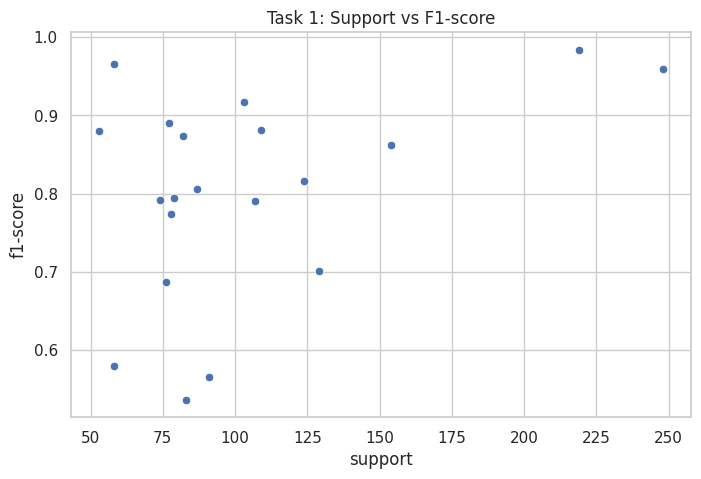

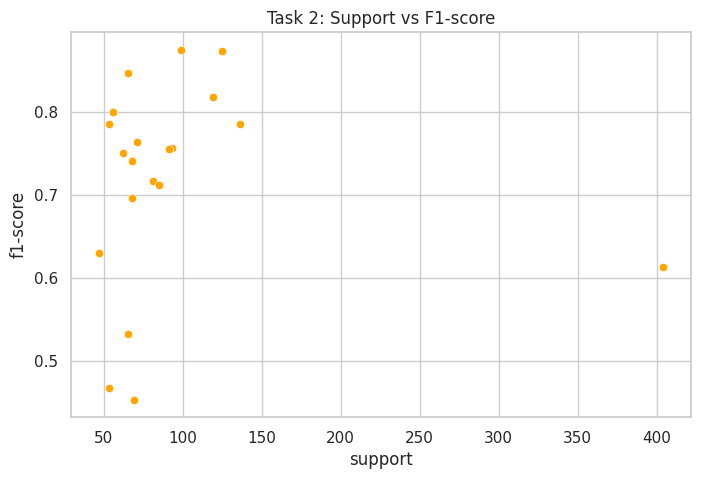

In [83]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=task1_report_clean,
    x="support",
    y="f1-score"
)
plt.title("Task 1: Support vs F1-score")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=task2_report_clean,
    x="support",
    y="f1-score",
    color="orange"
)
plt.title("Task 2: Support vs F1-score")
plt.show()


In [84]:
task1_freq = pd.read_csv("task1_class_distribution.csv")
task2_freq = pd.read_csv("task2_class_distribution.csv")

task1_analysis = task1_report_clean.reset_index().rename(columns={"index": "MstarGlobal"})
task1_analysis = task1_analysis.merge(task1_freq, on="MstarGlobal", how="left")

task2_analysis = task2_report_clean.reset_index().rename(columns={"index": "SubIndustry"})
task2_analysis = task2_analysis.merge(task2_freq, on="SubIndustry", how="left")

display(task1_analysis.head())
display(task2_analysis.head())


,MstarGlobal,precision,recall,f1-score,support,Count,Percent
0,Asset Management,0.967213,0.951613,0.959350,248.0,2359,4.40
1,Auto Parts,0.858824,0.890244,0.874251,82.0,826,1.54
2,Banks - Regional,0.990741,0.977169,0.983908,219.0,2165,4.04
3,Biotechnology,0.889655,0.837662,0.862876,154.0,1036,1.93
4,Chemicals,0.545455,0.620690,0.580645,58.0,709,1.32


,SubIndustry,precision,recall,f1-score,support,Count,Percent
0,Acquisition and Ownership of Buildings,0.776978,0.794118,0.785455,136.0,682,2.48
1,Automotive Parts Manufacturer,0.727273,0.774194,0.750000,62.0,309,1.12
2,Brokerage Services,0.750000,0.857143,0.800000,56.0,280,1.02
3,Business Productivity and Efficiency Software,0.460674,0.630769,0.532468,65.0,323,1.17
4,Business Support Services,0.400000,0.521739,0.452830,69.0,346,1.26


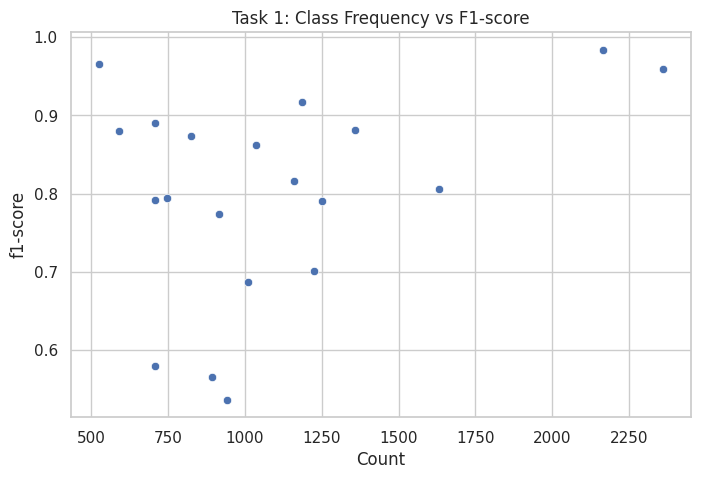

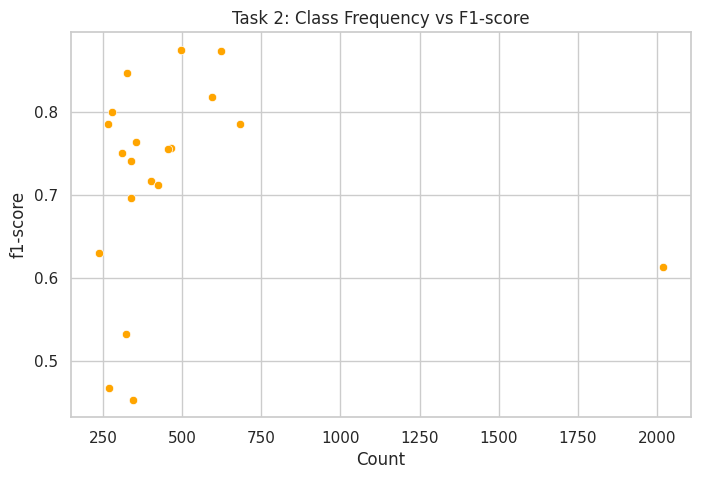

In [85]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=task1_analysis, x="Count", y="f1-score")
plt.title("Task 1: Class Frequency vs F1-score")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=task2_analysis, x="Count", y="f1-score", color="orange")
plt.title("Task 2: Class Frequency vs F1-score")
plt.show()


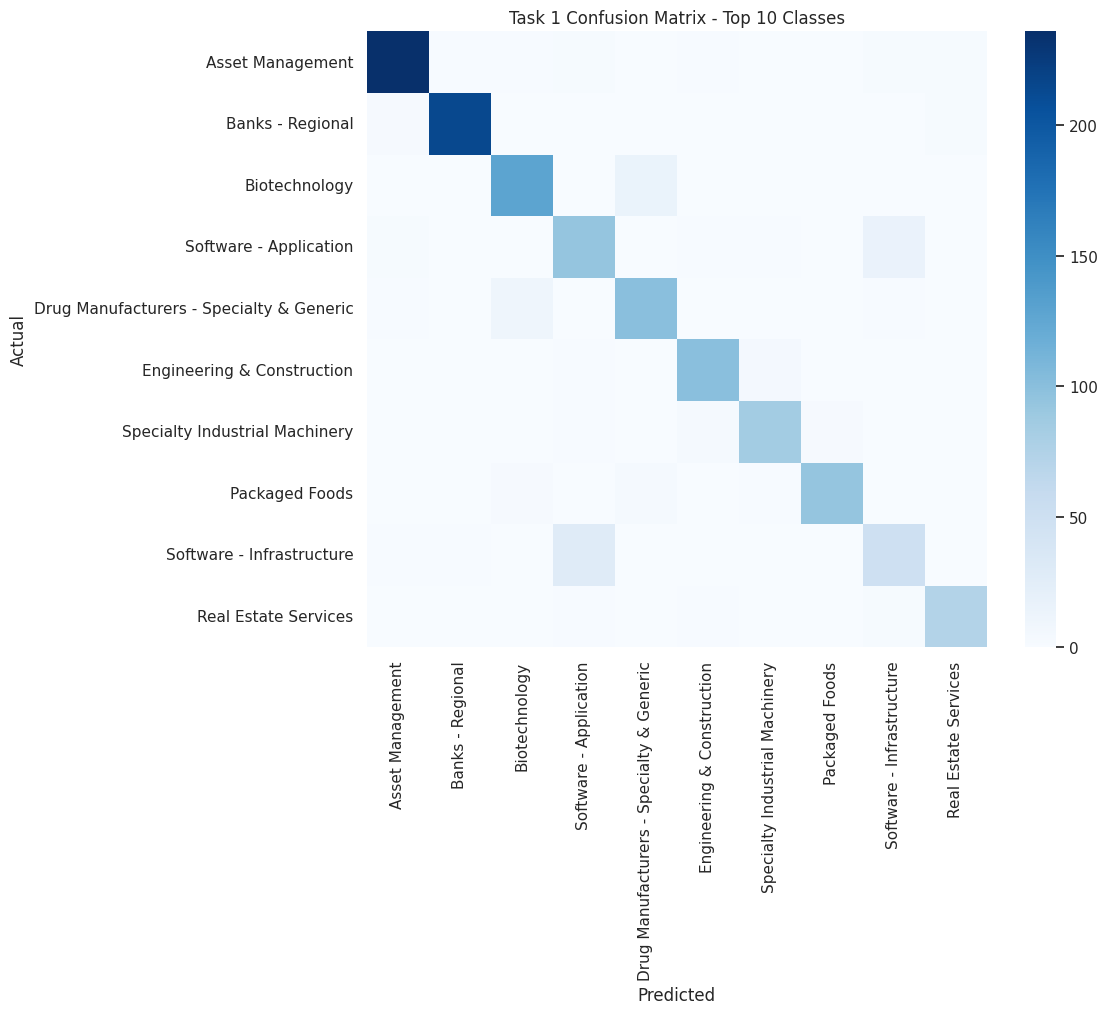

In [86]:
top10_task1 = test_df["MstarGlobal"].value_counts().head(10).index

task1_top_df = test_df[test_df["MstarGlobal"].isin(top10_task1)].copy()
task1_top_preds = task1_log_model.predict(task1_top_df["Combined_Text"])

cm_task1 = confusion_matrix(
    task1_top_df["MstarGlobal"],
    task1_top_preds,
    labels=top10_task1
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_task1,
    cmap="Blues",
    xticklabels=top10_task1,
    yticklabels=top10_task1
)
plt.title("Task 1 Confusion Matrix - Top 10 Classes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


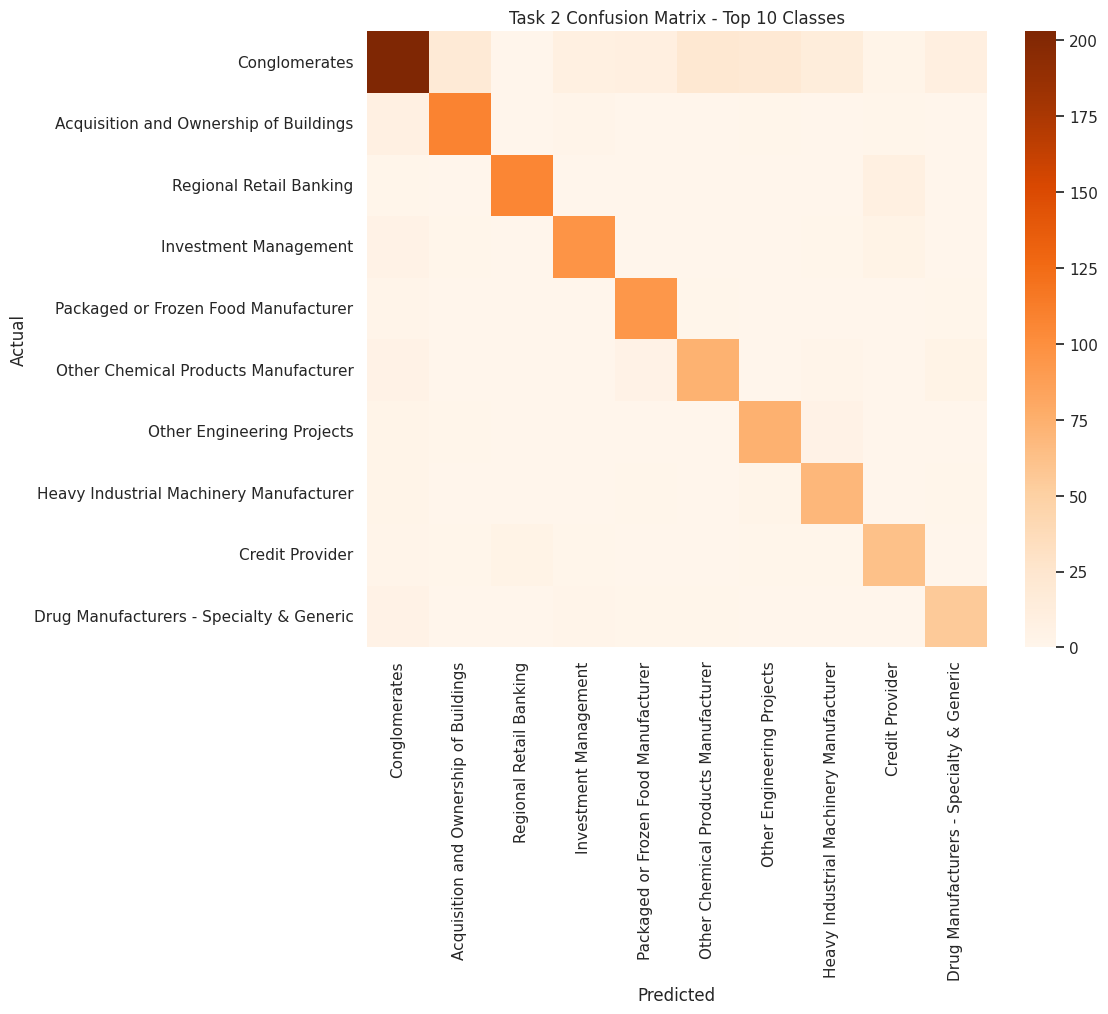

In [87]:
top10_task2 = test_df_task2["SubIndustry"].value_counts().head(10).index

task2_top_df = test_df_task2[test_df_task2["SubIndustry"].isin(top10_task2)].copy()
task2_top_preds = task2_log_model.predict(task2_top_df["Combined_Text"])

cm_task2 = confusion_matrix(
    task2_top_df["SubIndustry"],
    task2_top_preds,
    labels=top10_task2
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_task2,
    cmap="Oranges",
    xticklabels=top10_task2,
    yticklabels=top10_task2
)
plt.title("Task 2 Confusion Matrix - Top 10 Classes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


In [88]:
task1_analysis.to_csv("task1_error_analysis.csv", index=False)
task2_analysis.to_csv("task2_error_analysis.csv", index=False)

print("Saved:")
print("- task1_error_analysis.csv")
print("- task2_error_analysis.csv")


Saved:
- task1_error_analysis.csv
- task2_error_analysis.csv
